# Stage 2 (CLIP branch) — Flow Matching to Zero-Shot Text Prototypes

This notebook repeats `04_flow_matching.ipynb`'s Stage 2 experiment on the **other** Stage 1 prototype branch: frozen **CLIP RN50** image embeddings transported toward the frozen **text prototypes** from `03_zero_shot_clip.ipynb`, on DTD partition 1, FGVC-Aircraft (variant), and Flowers-102. Everything about the FM layer — velocity-network architecture, `T ∈ {4, 12}`, optimizer, schedule, checkpoint rule, K values, subset seeds — is read from the *same* `flow_matching` section of `stage1_config.json` that `04_flow_matching.ipynb` uses, so the two branches differ only in which encoder produces `z` and which prototypes are the transport target.

## Read this before reading the results

`ref/stage_2.pdf` says to apply the FM layer to *the* prototype branch selected in Stage 1, and `ref/stage_1.pdf` asks each group to pick **one** of the two. This notebook is therefore **not a required Stage 2 deliverable** — `04_flow_matching.ipynb` (image prototypes) is. It exists because this project implemented both Stage 1 branches (`prototype_branch: "all"`), and the CLIP branch is worth carrying forward as an extension. Two consequences follow, and both change how the numbers must be read:

1. **The FM layer is not zero-shot.** Standard and rolled-out FM both train on labeled pairs `(z_i, t_{y_i})`, so this converts zero-shot CLIP into a K-shot method. The zero-shot baseline is a single number per dataset with no `K` axis; the FM results have one. `ΔAcc = Acc_FM − Acc_zero-shot` therefore compares a *K-shot trained* model against a *zero-shot* baseline. That gap is real and worth reporting, but it is not the like-for-like comparison `04_flow_matching.ipynb` makes, where baseline and FM see exactly the same labeled images.
2. **Because of (1), Section 9 adds a K-shot control**: image-derived prototypes built from the same CLIP features and the same K-shot subsets (Stage 1 Option A's closed-form recipe, applied to CLIP). It is closed-form, costs nothing, and is the only way to separate *"the FM layer helps"* from *"having K labeled images per class helps"*. It is clearly marked as a control and is not part of Stage 2's required comparison.

## Design decisions

- **Both `z` and the text prototypes are already L2-normalized** — `03_zero_shot_clip.ipynb` normalizes at encode time, and this notebook asserts unit norm rather than assuming it. So the straight-line path `(1−t)z_i + t·t_{y_i}` connects two points of the same unit-norm space, matching the image-prototype branch's convention.
- **Text prototypes are fixed and K-independent.** Unlike image prototypes, `t_c` does not depend on `K` or on the subset seed, so a setting is identified by `(dataset, K, seed)` alone and the transport target is identical across all of them. Only the FM training subset varies.
- **Standard FM trains one network per setting** (its loss has no `T` dependency) evaluated at both `T`; **rolled-out FM trains one network per `T`**, since `T` is baked into its objective. Same asymmetry as the image branch.
- **Only train/val CLIP features are newly computed.** Stage 1 cached the CLIP *test* split only. Train and val are encoded here, once, into the same cache directory with the same convention. The test split and the text prototypes are loaded and never regenerated — a missing artifact fails loudly and points at `03_zero_shot_clip.ipynb`.

Run all cells top to bottom.

## 1. Install dependencies
`open_clip_torch` and `torchvision` are needed here (unlike `04_flow_matching.ipynb`), because the CLIP train/val image features do not exist yet and must be encoded once.

In [1]:
%pip -q install open_clip_torch scikit-learn pandas seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00


## 2. Mount Drive and configure paths
Same Drive project root as every other notebook, so the CLIP feature cache and the Stage 1 zero-shot outputs are visible without copying anything.

In [2]:
from pathlib import Path
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Flow-Matching')
else:
    PROJECT_ROOT = Path('/content/Flow-Matching')
DATA_ROOT = Path('/content/flow_matching_data') if Path('/content').exists() else PROJECT_ROOT / 'data'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'flow_matching_clip'
DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT, '| dataset root:', DATA_ROOT)
print('Stage 2 (CLIP branch) outputs:', OUTPUT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/Flow-Matching | dataset root: /content/flow_matching_data
Stage 2 (CLIP branch) outputs: /content/drive/MyDrive/Flow-Matching/outputs/flow_matching_clip


## 3. Imports, hardware, and the shared Stage 2 plan
The FM settings come from the **same** `flow_matching` config section `04_flow_matching.ipynb` wrote, and the CLIP settings from the **same** `zero_shot_clip` section `03_zero_shot_clip.ipynb` used. Neither is re-declared here — that is what makes the two Stage 2 branches comparable to each other and this branch faithful to Stage 1's CLIP setup.

In [3]:
import copy, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
import open_clip

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
print('Device:', DEVICE, '| GPU:', torch.cuda.get_device_name(0) if PIN_MEMORY else 'none')

# Identical to 04_flow_matching.ipynb's DEFAULT_FM_CONFIG; the cross-branch comparison depends on it.
DEFAULT_FM_CONFIG = {
    'config_revision': 1,
    'T_values': [4, 12],
    'hidden_dim': 512,
    'num_hidden_layers': 2,
    'batch_size': 64,
    'max_epochs': 200,
    'early_stopping_patience': 25,
    'lr_patience': 10,
    'min_delta': 1e-4,
    'checkpoint_interval': 10,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'resume_training': True,
}
config_paths = [
    PROJECT_ROOT / 'stage1_config.json',
    Path.cwd() / 'stage1_config.json',
    Path('/content/stage1_config.json'),
]
config_path = next((p for p in config_paths if p.exists()), None)
if config_path is None:
    raise FileNotFoundError('stage1_config.json not found. Run 01_linear_probe.ipynb first so the shared experiment plan exists.')
with config_path.open() as f:
    STAGE1 = json.load(f)
print('Loaded configuration from:', config_path)

if STAGE1.get('flow_matching', {}).get('config_revision', 0) < DEFAULT_FM_CONFIG['config_revision']:
    STAGE1['flow_matching'] = copy.deepcopy(DEFAULT_FM_CONFIG)
    config_path.write_text(json.dumps(STAGE1, indent=2))
    print('Added/updated flow_matching config section, revision:', STAGE1['flow_matching']['config_revision'])

PLAN, FM = STAGE1['plan'], STAGE1['flow_matching']
DATASETS = PLAN['datasets']
SHOT_SETTINGS = PLAN['shots']
SUBSET_SEEDS = PLAN['subset_seeds']
INIT_SEEDS = PLAN['init_seeds']

# 03_zero_shot_clip.ipynb holds its CLIP settings in an embedded default and never writes them back, so
# stage1_config.json legitimately may have no 'zero_shot_clip' section. Falling back to *exactly* those
# embedded values is what keeps the cache path and the prompt templates pointing at the artifacts that
# notebook actually produced - a different default here would silently look in the wrong directory.
DEFAULT_CLIP_CONFIG = {
    'output_subdir': 'zero_shot_clip',
    'model_name': 'RN50',
    'pretrained': 'openai',
    'force_quick_gelu': True,
    'cache_schema_version': 2,
    'primary_variant': 'prescribed',
    'prompt_variants': {'prescribed': {'dtd': ['a photo of a {class_name} texture'],
                                       'aircraft': ['a photo of a {class_name} aircraft'],
                                       'flowers102': ['a photo of a {class_name} flower']}},
}
CLIP_CFG = STAGE1.get('zero_shot_clip')
if CLIP_CFG is None:
    CLIP_CFG = DEFAULT_CLIP_CONFIG
    print("No 'zero_shot_clip' section in stage1_config.json - using the same embedded defaults 03_zero_shot_clip.ipynb uses.")
else:
    print("Using the 'zero_shot_clip' section from stage1_config.json.")
branches = PLAN.get('prototype_branches') or [PLAN.get('prototype_branch')]
if not ({'zero_shot_clip', 'all'} & set(branches)):
    print(f'NOTE: prototype_branches={branches} does not list zero_shot_clip. Continuing anyway - the check that '
          f'actually matters is whether 03_zero_shot_clip.ipynb left its cached artifacts on Drive, verified below.')
MODEL_NAME = CLIP_CFG.get('model_name', 'RN50')
PRETRAINED = CLIP_CFG.get('pretrained', 'openai')
FORCE_QUICK_GELU = bool(CLIP_CFG.get('force_quick_gelu', True))
CACHE_SCHEMA = int(CLIP_CFG.get('cache_schema_version', 2))
PRIMARY_VARIANT = CLIP_CFG.get('primary_variant', 'prescribed')
ENCODER_TAG = f'clip_{MODEL_NAME.lower()}'
CLIP_CACHE_ROOT = PROJECT_ROOT / 'feature_cache' / f'clip_{MODEL_NAME.lower()}_{PRETRAINED}_qgelu{int(FORCE_QUICK_GELU)}_v{CACHE_SCHEMA}'
ZERO_SHOT_ROOT = PROJECT_ROOT / 'outputs' / CLIP_CFG.get('output_subdir', 'zero_shot_clip')
BATCH_SIZE_IMAGES = min(STAGE1['feature_cache']['batch_size'], 64)
NUM_WORKERS = 0 if Path('/content').exists() else STAGE1['feature_cache']['num_workers']

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(0)
print('Datasets:', DATASETS, '| shots:', SHOT_SETTINGS, '| T values:', FM['T_values'])
print('CLIP:', MODEL_NAME, PRETRAINED, '| QuickGELU:', FORCE_QUICK_GELU, '| prompt variant:', PRIMARY_VARIANT)
print('CLIP feature cache:', CLIP_CACHE_ROOT)
print('Stage 1 zero-shot outputs:', ZERO_SHOT_ROOT)

# Fail here, with the resolved path and the settings that produced it, rather than deep inside Section 6.
if not CLIP_CACHE_ROOT.exists():
    raise FileNotFoundError(
        f'CLIP feature cache directory not found: {CLIP_CACHE_ROOT}\n'
        f'Run 03_zero_shot_clip.ipynb first. If it has already been run, its CLIP settings differ from the ones '
        f'resolved here (model={MODEL_NAME}, pretrained={PRETRAINED}, QuickGELU={FORCE_QUICK_GELU}, '
        f'cache schema=v{CACHE_SCHEMA}); make the two match before continuing.')
cached_artifacts = sorted(p.name for p in CLIP_CACHE_ROOT.glob('*.pt'))
print('Cached CLIP artifacts on Drive:', cached_artifacts if cached_artifacts else '(none)')
missing_text = [f'{d}__text_{PRIMARY_VARIANT}.pt' for d in DATASETS
                if not (CLIP_CACHE_ROOT / f'{d}__text_{PRIMARY_VARIANT}.pt').exists()]
if missing_text:
    raise FileNotFoundError(
        f'Missing Stage 1 CLIP text prototypes: {missing_text} in {CLIP_CACHE_ROOT}. '
        f'Run 03_zero_shot_clip.ipynb (Section 7) first.')

Device: cuda | GPU: Tesla T4
Loaded configuration from: /content/drive/MyDrive/Flow-Matching/stage1_config.json
No 'zero_shot_clip' section in stage1_config.json - using the same embedded defaults 03_zero_shot_clip.ipynb uses.
Datasets: ['dtd', 'aircraft', 'flowers102'] | shots: [5, 10, 'full'] | T values: [4, 12]
CLIP: RN50 openai | QuickGELU: True | prompt variant: prescribed
CLIP feature cache: /content/drive/MyDrive/Flow-Matching/feature_cache/clip_rn50_openai_qgelu1_v2
Stage 1 zero-shot outputs: /content/drive/MyDrive/Flow-Matching/outputs/zero_shot_clip
Cached CLIP artifacts on Drive: ['aircraft__test.pt', 'aircraft__text_ensemble.pt', 'aircraft__text_prescribed.pt', 'aircraft__text_prototypes.pt', 'aircraft__train.pt', 'aircraft__val.pt', 'dtd__test.pt', 'dtd__text_ensemble.pt', 'dtd__text_prescribed.pt', 'dtd__text_prototypes.pt', 'dtd__train.pt', 'dtd__val.pt', 'flowers102__test.pt', 'flowers102__text_ensemble.pt', 'flowers102__text_prescribed.pt', 'flowers102__text_prototypes

## 4. Class names and the Stage 1 prompt templates
Copied unchanged from `03_zero_shot_clip.ipynb`. These are needed only to **validate** the cached text prototypes — the prototypes themselves are never re-encoded here, but the cache is checked against the exact class-name list and prompt templates it claims to have been built from, so a silently mismatched artifact is caught instead of used.

In [4]:
FLOWERS102_CLASSES = [
'pink primrose','hard-leaved pocket orchid','canterbury bells','sweet pea','english marigold','tiger lily','moon orchid','bird of paradise','monkshood','globe thistle',
'snapdragon','colts foot','king protea','spear thistle','yellow iris','globe-flower','purple coneflower','peruvian lily','balloon flower','giant white arum lily',
'fire lily','pincushion flower','fritillary','red ginger','grape hyacinth','corn poppy','prince of wales feathers','stemless gentian','artichoke','sweet william',
'carnation','garden phlox','love in the mist','mexican aster','alpine sea holly','ruby-lipped cattleya','cape flower','great masterwort','siam tulip','lenten rose',
'barbeton daisy','daffodil','sword lily','poinsettia','bolero deep blue','wallflower','marigold','buttercup','oxeye daisy','common dandelion',
'petunia','wild pansy','primula','sunflower','pelargonium','bishop of llandaff','gaura','geranium','orange dahlia','pink-yellow dahlia',
'cautleya spicata','japanese anemone','black-eyed susan','silverbush','californian poppy','osteospermum','spring crocus','bearded iris','windflower','tree poppy',
'gazania','azalea','water lily','rose','thorn apple','morning glory','passion flower','lotus','toad lily','anthurium',
'frangipani','clematis','hibiscus','columbine','desert-rose','tree mallow','magnolia','cyclamen','watercress','canna lily',
'hippeastrum','bee balm','ball moss','foxglove','bougainvillea','camellia','mallow','mexican petunia','bromelia','blanket flower','trumpet creeper','blackberry lily']
assert len(FLOWERS102_CLASSES) == 102

PRESCRIBED = {'dtd': ['a photo of a {class_name} texture'],
              'aircraft': ['a photo of a {class_name} aircraft'],
              'flowers102': ['a photo of a {class_name} flower']}
PROMPT_VARIANTS = CLIP_CFG.get('prompt_variants', {'prescribed': PRESCRIBED})
assert PRIMARY_VARIANT in PROMPT_VARIANTS and set(DATASETS) <= set(PROMPT_VARIANTS[PRIMARY_VARIANT]), \
    'The primary prompt variant does not cover every dataset.'
print('Prompt templates in use:', {d: PROMPT_VARIANTS[PRIMARY_VARIANT][d] for d in DATASETS})

Prompt templates in use: {'dtd': ['a photo of a {class_name} texture'], 'aircraft': ['a photo of a {class_name} aircraft'], 'flowers102': ['a photo of a {class_name} flower']}


## 5. Load the frozen CLIP RN50 encoder and build the official splits
Same checkpoint, same preprocessing, and the same `build_dataset` / `targets_of` / `class_names_of` helpers as `03_zero_shot_clip.ipynb`, extended from test-only to all three official splits. All CLIP parameters stay frozen — only `v_theta` ever receives gradients in this notebook.

In [5]:
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED, force_quick_gelu=FORCE_QUICK_GELU)
model.eval().to(DEVICE)
for p in model.parameters():
    p.requires_grad_(False)
assert not any(p.requires_grad for p in model.parameters())

def build_dataset(name, split, transform):
    if name == 'dtd': return datasets.DTD(DATA_ROOT, split=split, partition=1, transform=transform, download=True)
    if name == 'aircraft': return datasets.FGVCAircraft(DATA_ROOT, split=split, annotation_level='variant', transform=transform, download=True)
    if name == 'flowers102': return datasets.Flowers102(DATA_ROOT, split=split, transform=transform, download=True)
    raise ValueError(name)

def targets_of(ds):
    for attr in ('_labels', 'targets', 'labels'):
        if hasattr(ds, attr): return np.asarray(getattr(ds, attr), dtype=int)
    return np.asarray([ds[i][1] for i in range(len(ds))], dtype=int)

def class_names_of(name, ds):
    if name == 'flowers102': return FLOWERS102_CLASSES
    if hasattr(ds, 'classes'): return [str(x).replace('_', ' ') for x in ds.classes]
    raise AttributeError(f'No class names exposed for {name}')

print('Frozen CLIP', MODEL_NAME, 'loaded | embed dim:', model.text_projection.shape[-1] if hasattr(model, 'text_projection') else 'n/a')

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  408MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

Frozen CLIP RN50 loaded | embed dim: 1024


## 6. Cache CLIP features for all three splits
`encode_split` is the only place in this notebook that runs an encoder. It encodes **train and val only** — those genuinely do not exist yet, because `03_zero_shot_clip.ipynb` cached the test split alone — writing them into the same cache directory, with the same `normalize`-at-encode-time convention and the same `shuffle=False` ordering Stage 1 used. The **test** split and the **text prototypes** are Stage 1 artifacts: they are loaded, verified, and never regenerated, so a missing one fails loudly instead of producing a second, possibly different, copy.

The unit-norm assertions verify the design decision stated at the top rather than assuming it: FM's straight-line path is only geometrically meaningful if `z` and `t_c` live on the same unit sphere.

In [6]:
@torch.inference_mode()
def encode_split(name, split):
    cache = CLIP_CACHE_ROOT / f'{name}__{split}.pt'
    if cache.exists():
        return torch.load(cache, map_location='cpu', weights_only=False)
    if split == 'test':
        raise FileNotFoundError(f'Missing Stage 1 CLIP test cache: {cache}. Run 03_zero_shot_clip.ipynb first.')
    CLIP_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
    ds = build_dataset(name, split, preprocess)
    loader = DataLoader(ds, batch_size=BATCH_SIZE_IMAGES, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    zs, ys = [], []
    for images, labels in tqdm(loader, desc=f'CLIP {MODEL_NAME} / {name} / {split}'):
        zs.append(F.normalize(model.encode_image(images.to(DEVICE, non_blocking=True)).float(), dim=1).cpu())
        ys.append(labels.long())
    item = dict(features=torch.cat(zs), labels=torch.cat(ys), classes=class_names_of(name, ds), dataset=name,
                split=split, encoder=f'CLIP {MODEL_NAME}', model_name=MODEL_NAME, pretrained=PRETRAINED,
                force_quick_gelu=FORCE_QUICK_GELU, cache_schema=CACHE_SCHEMA)
    assert len(item['features']) == len(ds) and torch.isfinite(item['features']).all()
    torch.save(item, cache)
    return item

def load_text_prototypes(name, class_names):
    cache = CLIP_CACHE_ROOT / f'{name}__text_{PRIMARY_VARIANT}.pt'
    if not cache.exists():
        raise FileNotFoundError(f'Missing Stage 1 CLIP text prototypes: {cache}. Run 03_zero_shot_clip.ipynb first.')
    cached = torch.load(cache, map_location='cpu', weights_only=False)
    templates = PROMPT_VARIANTS[PRIMARY_VARIANT][name]
    assert cached['classes'] == class_names, f'{name}: cached text prototypes were built for different class names.'
    assert cached['templates'] == templates, f'{name}: cached text prototypes were built from different prompts.'
    return cached['features'].float()

feature_bank, text_bank, cache_rows = {}, {}, []
for name in DATASETS:
    feature_bank[name] = {split: encode_split(name, split) for split in ('train', 'val', 'test')}
    classes = feature_bank[name]['test']['classes']
    for split in ('train', 'val'):
        assert feature_bank[name][split]['classes'] == classes, f'{name}: class-name order differs between splits.'
    text_bank[name] = load_text_prototypes(name, classes)
    for split in ('train', 'val', 'test'):
        norms = feature_bank[name][split]['features'].norm(dim=1)
        assert torch.allclose(norms, torch.ones_like(norms), atol=1e-3), f'{name}/{split}: image features are not unit-norm.'
    tnorms = text_bank[name].norm(dim=1)
    assert torch.allclose(tnorms, torch.ones_like(tnorms), atol=1e-3), f'{name}: text prototypes are not unit-norm.'
    assert len(text_bank[name]) == len(classes)
    cache_rows.append(dict(dataset=name, classes=len(classes), feature_dim=text_bank[name].shape[1],
                           **{f'{s}_images': len(feature_bank[name][s]['labels']) for s in ('train', 'val', 'test')}))
display(pd.DataFrame(cache_rows))
print('All image features and text prototypes verified unit-norm.')

,dataset,classes,feature_dim,train_images,val_images,test_images
0,dtd,47,1024,1880,1880,1880
1,aircraft,100,1024,3334,3333,3333
2,flowers102,102,1024,1020,1020,6149


All image features and text prototypes verified unit-norm.


## 7. Reproduce the Stage 1 zero-shot baseline from the cache
The baseline is recomputed here from the cached embeddings and then checked against the number `03_zero_shot_clip.ipynb` already reported. This is a guard, not a re-run: if the two disagree the caches have drifted and every `ΔAcc` below would be measured against the wrong reference, so it fails rather than silently reporting a different baseline than Stage 1 did.

In [7]:
zero_shot = pd.DataFrame([
    dict(dataset=name,
         zero_shot_accuracy=((feature_bank[name]['test']['features'] @ text_bank[name].T).argmax(1)
                             == feature_bank[name]['test']['labels']).float().mean().item())
    for name in DATASETS])

stage1_path = ZERO_SHOT_ROOT / 'accuracy_summary.csv'
if stage1_path.exists():
    reported = pd.read_csv(stage1_path)[['dataset', 'test_accuracy']].rename(columns={'test_accuracy': 'stage1_reported'})
    zero_shot = zero_shot.merge(reported, on='dataset', how='left')
    drift = (zero_shot.zero_shot_accuracy - zero_shot.stage1_reported).abs().max()
    assert drift < 1e-6, f'Recomputed zero-shot accuracy drifted from Stage 1 by {drift:.2e}; the caches disagree.'
    print(f'Zero-shot baseline reproduced from cache; max drift vs. Stage 1: {drift:.2e}')
else:
    print('Stage 1 zero_shot_clip/accuracy_summary.csv not found; using the freshly recomputed baseline.')
zero_shot.to_csv(OUTPUT_ROOT / 'zero_shot_baseline.csv', index=False)
display(zero_shot.style.format({'zero_shot_accuracy': '{:.4f}', 'stage1_reported': '{:.4f}'}))

Zero-shot baseline reproduced from cache; max drift vs. Stage 1: 5.55e-17


,dataset,zero_shot_accuracy,stage1_reported
0,dtd,0.3979,0.3979
1,aircraft,0.1704,0.1704
2,flowers102,0.6360,0.6360


## 8. Balanced subsets, the Euler integrator, and a repetition-count check

`balanced_indices` is copied verbatim from Stage 1 so the K-shot subsets are the same images the other notebooks use for a given seed. `euler_rollout` is the single differentiable integrator shared by inference, rolled-out training, and the trajectory plots.

The diagnostic table exists because **a "3-run mean ± std" is only honest if the 3 runs actually differ.** Flowers-102's official train split holds exactly 10 images per class, so at `K=10` all three subset seeds select the identical 1020 images and — since non-`full` settings also share `init_seed=0` — all three repetitions are the same run, with a standard deviation of exactly 0. The table reports the number of *distinct* subsets per setting so that gets stated rather than discovered in the error bars.

In [8]:
def balanced_indices(labels, k, seed):
    labels = np.asarray(labels); rng = np.random.default_rng(seed); chosen = []
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        if len(idx) < k: raise ValueError(f'class {c} has {len(idx)} samples, fewer than K={k}')
        chosen.extend(rng.choice(idx, size=k, replace=False).tolist())
    return np.asarray(sorted(chosen))

def euler_rollout(v_theta, z0, T, return_trajectory=False):
    z = z0
    trajectory = [z0.detach().clone()] if return_trajectory else None
    for k in range(T):
        t = torch.full((z.shape[0],), k / T, device=z.device, dtype=z.dtype)
        z = z + (1.0 / T) * v_theta(z, t)
        if return_trajectory: trajectory.append(z.detach().clone())
    return (z, trajectory) if return_trajectory else z

def classify_cosine(z, prototypes):
    scores = F.normalize(z, dim=1) @ F.normalize(prototypes, dim=1).T
    return scores.argmax(1), scores

rows = []
for name in DATASETS:
    y = feature_bank[name]['train']['labels'].numpy()
    n_classes = len(np.unique(y))
    for shot in SHOT_SETTINGS:
        if shot == 'full':
            distinct, size, effective = 1, len(y), len(INIT_SEEDS)
        else:
            distinct = len({tuple(balanced_indices(y, int(shot), s).tolist()) for s in SUBSET_SEEDS})
            size, effective = int(shot) * n_classes, distinct
        rows.append(dict(dataset=name, shot=str(shot), train_images=len(y), subset_size=size,
                         distinct_subsets=distinct, effective_repetitions=effective))
subset_diagnostics = pd.DataFrame(rows)
subset_diagnostics.to_csv(OUTPUT_ROOT / 'subset_diagnostics.csv', index=False)
display(subset_diagnostics)
for r in subset_diagnostics.itertuples():
    if r.shot != 'full' and r.distinct_subsets < len(SUBSET_SEEDS):
        print(f'NOTE: {r.dataset} K={r.shot} — the official train split holds only {r.train_images} images, so all '
              f'{len(SUBSET_SEEDS)} subset seeds select the same {r.subset_size}. Report it as {r.distinct_subsets} '
              f'effective run; its standard deviation will be exactly 0 by construction, not by low variance.')

,dataset,shot,train_images,subset_size,distinct_subsets,effective_repetitions
0,dtd,5,1880,235,3,3
1,dtd,10,1880,470,3,3
2,dtd,full,1880,1880,1,3
3,aircraft,5,3334,500,3,3
4,aircraft,10,3334,1000,3,3
5,aircraft,full,3334,3334,1,3
6,flowers102,5,1020,510,3,3
7,flowers102,10,1020,1020,1,1
8,flowers102,full,1020,1020,1,3


NOTE: flowers102 K=10 — the official train split holds only 1020 images, so all 3 subset seeds select the same 1020. Report it as 1 effective run; its standard deviation will be exactly 0 by construction, not by low variance.


## 9. K-shot control: image prototypes from the same CLIP features

Not part of Stage 2's required comparison — see the framing note at the top. Since the FM layer consumes K labeled images per class and the zero-shot baseline consumes none, `ΔAcc` against zero-shot alone cannot distinguish *"the FM layer helps"* from *"K labels help"*. This control closes that gap the cheapest possible way: Stage 1 Option A's closed-form recipe (`normalize → class mean → normalize`, copied verbatim from `02_image_prototypes.ipynb`) applied to the same CLIP features and the same K-shot subsets, classified with the same cosine rule.

It gives a second reference line that consumes exactly the supervision the FM layer does, with zero trained parameters. FM beating *this* is evidence about the FM layer; FM beating zero-shot is mostly evidence about having labels.

In [ ]:
def make_prototypes(features, labels, n_classes):
    features = F.normalize(features.float(), dim=1)
    prototypes = torch.stack([features[labels == c].mean(0) for c in range(n_classes)])
    assert torch.isfinite(prototypes).all()
    return F.normalize(prototypes, dim=1)

# The control's per-run PREDICTIONS are saved here, not only its accuracy. Section 19 pairs FM
# against this control on the same test images, and McNemar needs the predictions themselves.
# The control is closed form, so regenerating them costs nothing.
CONTROL_ROOT = OUTPUT_ROOT / 'controls'

control_rows = []
for name in DATASETS:
    bank = feature_bank[name]
    x_train, y_train_full = bank['train']['features'].float(), bank['train']['labels'].long()
    x_test, y_test = bank['test']['features'].float(), bank['test']['labels'].long()
    n_classes = len(bank['test']['classes'])
    for shot in SHOT_SETTINGS:
        seeds = SUBSET_SEEDS if shot != 'full' else [0]  # closed form: the full setting has nothing to reseed
        for seed in seeds:
            if shot != 'full':
                idx = torch.as_tensor(balanced_indices(y_train_full.numpy(), int(shot), seed))
                xs, ys = x_train[idx], y_train_full[idx]
            else:
                xs, ys = x_train, y_train_full
            protos = make_prototypes(xs, ys, n_classes)
            pred, _ = classify_cosine(x_test, protos)
            run_dir = CONTROL_ROOT / name / str(shot) / f'seed_{seed}'
            run_dir.mkdir(parents=True, exist_ok=True)
            np.save(run_dir / 'test_predictions.npy', pred.cpu().numpy())
            control_rows.append(dict(dataset=name, shot=str(shot), seed=seed,
                                     test_accuracy=(pred == y_test).float().mean().item()))
control_df = pd.DataFrame(control_rows)
control_df.to_csv(OUTPUT_ROOT / 'image_prototype_control_runs.csv', index=False)
control_summary = control_df.groupby(['dataset', 'shot'], as_index=False).agg(
    control_mean_accuracy=('test_accuracy', 'mean'), control_std_accuracy=('test_accuracy', 'std'),
    control_runs=('test_accuracy', 'size'))
control_summary.to_csv(OUTPUT_ROOT / 'image_prototype_control.csv', index=False)
print(f'Per-run control predictions saved under {CONTROL_ROOT} (needed by Section 19).')
display(control_summary.style.format({'control_mean_accuracy': '{:.4f}', 'control_std_accuracy': '{:.4f}'}))

## 10. Velocity network and checkpointed training

`VelocityNet` is the MLP `ref/stage_2.pdf` suggests — 2 hidden layers of width 512, SiLU, scalar `t` concatenated to the feature, output dimension equal to the feature dimension (1024 for CLIP RN50). `train_velocity_network` trains either objective (`mode='standard'` or `'rollout'`) with the same checkpoint/resume machinery as the rest of the project: checkpoint on best validation accuracy with early stopping, periodic `latest.pt` snapshots so a long grid survives a disconnect, and a config-compatibility check before resuming so a changed setting retrains instead of silently continuing from a stale checkpoint.

Checkpoint selection mirrors Stage 1's "highest validation accuracy" rule. For rolled-out training that is unambiguous (accuracy at that network's own `T`); for standard training it is the **mean** of validation accuracy over every `T` in `T_values`, since one standard network is later judged at all of them. Both the selection score *and* the per-`T` validation accuracies at the selected epoch are recorded, so a per-`T` row in the results CSV never reports the averaged number as if it were that `T`'s own.

In [10]:
class VelocityNet(nn.Module):
    def __init__(self, feature_dim, hidden_dim, num_hidden_layers):
        super().__init__()
        layers = []
        in_dim = feature_dim + 1
        for _ in range(num_hidden_layers):
            layers += [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, feature_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, t):
        if t.dim() == 0: t = t.expand(z.shape[0])
        return self.net(torch.cat([z, t.view(-1, 1).to(z.dtype)], dim=1))

def validation_accuracies(net, x_val, y_val, prototypes, T_list):
    was_training = net.training
    net.eval()
    accs = {}
    with torch.no_grad():
        for T in T_list:
            pred, _ = classify_cosine(euler_rollout(net, x_val, T), prototypes)
            accs[T] = (pred == y_val).float().mean().item()
    net.train(was_training)
    return accs

def train_velocity_network(mode, x_train, y_train, prototypes, x_val, y_val, run_dir,
                            dataset_name, shot, subset_seed, init_seed, T=None):
    """x_train/y_train/x_val/y_val/prototypes must already be on DEVICE. `mode` is 'standard' or
    'rollout'; for 'rollout', T is required and fixed for the whole run (training and inference use the
    same T, per the PDF). Returns (net, history, best_acc, best_accs_by_T, runtime_seconds, start_epoch)."""
    seed_everything(init_seed)
    feature_dim = x_train.shape[1]; num_classes = prototypes.shape[0]
    net = VelocityNet(feature_dim, FM['hidden_dim'], FM['num_hidden_layers']).to(DEVICE)
    optimizer = torch.optim.AdamW(net.parameters(), lr=FM['learning_rate'], weight_decay=FM['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=FM['lr_patience'])
    eval_T_list = list(FM['T_values']) if mode == 'standard' else [T]
    best_acc, best_accs, best_state, history, start_epoch, stale_epochs = -1.0, None, None, [], 1, 0

    checkpoint_dir = run_dir / 'checkpoints'; checkpoint_dir.mkdir(parents=True, exist_ok=True)
    latest_path, best_path = checkpoint_dir / 'latest.pt', checkpoint_dir / 'best.pt'
    run_config = dict(dataset=dataset_name, encoder=ENCODER_TAG, shot=str(shot), subset_seed=subset_seed,
                      init_seed=init_seed, mode=mode, T=T, feature_dim=feature_dim, num_classes=num_classes,
                      hidden_dim=FM['hidden_dim'], num_hidden_layers=FM['num_hidden_layers'],
                      learning_rate=FM['learning_rate'], weight_decay=FM['weight_decay'],
                      prototype_source=f'clip_text_{PRIMARY_VARIANT}')
    (run_dir / 'config.json').write_text(json.dumps(run_config, indent=2))

    if FM['resume_training'] and latest_path.exists():
        checkpoint = torch.load(latest_path, map_location=DEVICE, weights_only=False)
        old_config = checkpoint.get('config', {})
        required_keys = ['dataset', 'encoder', 'shot', 'subset_seed', 'init_seed', 'mode', 'T',
                         'feature_dim', 'num_classes', 'hidden_dim', 'num_hidden_layers', 'prototype_source']
        if all(old_config.get(k) == run_config.get(k) for k in required_keys):
            net.load_state_dict(checkpoint['model_state_dict']); optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if checkpoint.get('scheduler_state_dict') is not None: scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            start_epoch = checkpoint['epoch'] + 1; best_acc = checkpoint['best_val_accuracy']
            best_accs = checkpoint.get('best_val_accuracies'); best_state = checkpoint['best_model_state_dict']
            history = checkpoint['history']; stale_epochs = checkpoint.get('stale_epochs', 0)
            print(f'Resuming {run_dir} from epoch {start_epoch}')
        else:
            print(f'Checkpoint configuration changed for {run_dir}; starting a fresh run.')

    def save_checkpoint(path, epoch):
        torch.save(dict(epoch=epoch, model_state_dict=net.state_dict(), optimizer_state_dict=optimizer.state_dict(),
                        scheduler_state_dict=scheduler.state_dict(), best_model_state_dict=best_state,
                        best_val_accuracy=best_acc, best_val_accuracies=best_accs, stale_epochs=stale_epochs,
                        history=history, config=run_config), path)

    started = time.perf_counter()
    n_train = x_train.shape[0]
    for epoch in range(start_epoch, FM['max_epochs'] + 1):
        generator = torch.Generator().manual_seed(init_seed * 100000 + epoch)
        perm = torch.randperm(n_train, generator=generator)
        net.train(); train_total = 0.0
        for start in range(0, n_train, FM['batch_size']):
            batch_idx = perm[start:start + FM['batch_size']]
            zb, yb = x_train[batch_idx], y_train[batch_idx]
            pb = prototypes[yb]
            optimizer.zero_grad(set_to_none=True)
            if mode == 'standard':
                t = torch.rand(zb.shape[0], device=DEVICE)
                zt = (1 - t.view(-1, 1)) * zb + t.view(-1, 1) * pb
                loss = F.mse_loss(net(zt, t), pb - zb)
            else:
                loss = F.mse_loss(euler_rollout(net, zb, T), pb)
            loss.backward(); optimizer.step()
            train_total += loss.item() * len(batch_idx)
        val_accs = validation_accuracies(net, x_val, y_val, prototypes, eval_T_list)
        val_acc = float(np.mean(list(val_accs.values())))
        record = dict(epoch=epoch, train_loss=train_total / n_train, val_accuracy=val_acc)
        record.update({f'val_accuracy_T{T_}': a for T_, a in val_accs.items()})
        history.append(record)
        if val_acc > best_acc + FM['min_delta']:
            best_acc, best_accs = val_acc, dict(val_accs)
            best_state = copy.deepcopy(net.state_dict()); stale_epochs = 0; save_checkpoint(best_path, epoch)
        else:
            stale_epochs += 1
        scheduler.step(val_acc)
        if epoch % FM['checkpoint_interval'] == 0: save_checkpoint(latest_path, epoch)
        if stale_epochs >= FM['early_stopping_patience']:
            save_checkpoint(latest_path, epoch); print(f'Early stopping at epoch {epoch}'); break
    if history: save_checkpoint(latest_path, history[-1]['epoch'])
    if best_state is None: best_state = copy.deepcopy(net.state_dict())
    if best_accs is None: best_accs = {T_: float('nan') for T_ in eval_T_list}
    runtime_seconds = time.perf_counter() - started
    net.load_state_dict(best_state); net.eval()
    pd.DataFrame(history).to_csv(run_dir / 'history.csv', index=False)
    return net, history, best_acc, best_accs, runtime_seconds, start_epoch

def evaluate_split(net, x, y, prototypes, T):
    net.eval()
    with torch.no_grad():
        pred, _ = classify_cosine(euler_rollout(net, x, T), prototypes)
        return (pred == y).float().mean().item(), pred.cpu()

def load_trained_network(dataset_name, shot, subset_seed, init_seed, mode_tag, feature_dim):
    run_dir = OUTPUT_ROOT / 'runs' / dataset_name / ENCODER_TAG / str(shot) / mode_tag / f'subset_{subset_seed}__init_{init_seed}'
    checkpoint = torch.load(run_dir / 'checkpoints' / 'best.pt', map_location=DEVICE, weights_only=False)
    net = VelocityNet(feature_dim, FM['hidden_dim'], FM['num_hidden_layers']).to(DEVICE)
    net.load_state_dict(checkpoint.get('best_model_state_dict') or checkpoint['model_state_dict'])
    net.eval()
    return net

## 11. Run the complete experiment grid

`3 datasets × 3 K values × 3 repetitions × 3 networks` (one standard, one rolled-out per `T`) = **81 trainings**, producing `81 × 4 / 3 = 108` result rows. `FORCE_RETRAIN = False` skips any setting whose `metrics.json` and `test_predictions.npy` are already on Drive, so re-running after a disconnect only retrains what is genuinely missing.

The transport target is `text_bank[dataset]` — the same fixed text prototypes for every `K` and every seed, since text prototypes carry no dependence on the labeled subset. That is the one structural difference from `04_flow_matching.ipynb`, where the prototype itself is rebuilt per `(K, seed)`.

In [11]:
def load_completed_metrics(eval_dir):
    metrics_path, pred_path = eval_dir / 'metrics.json', eval_dir / 'test_predictions.npy'
    if not (metrics_path.exists() and pred_path.exists()):
        return None
    return json.loads(metrics_path.read_text())

def load_completed_history(run_dir):
    history_path = run_dir / 'history.csv'
    return pd.read_csv(history_path).to_dict('records') if history_path.exists() else None

FORCE_RETRAIN = False  # set True to ignore saved FM results on Drive and retrain everything

def run_fm_setting(dataset_name, shot, subset_seed, init_seed):
    bank = feature_bank[dataset_name]
    x_train_raw, y_train_full = bank['train']['features'].float(), bank['train']['labels'].long()
    if shot != 'full':
        idx = torch.as_tensor(balanced_indices(y_train_full.numpy(), int(shot), subset_seed))
        x_train_raw, y_train = x_train_raw[idx], y_train_full[idx]
    else:
        y_train = y_train_full
    x_train = F.normalize(x_train_raw, dim=1).to(DEVICE); y_train = y_train.to(DEVICE)
    x_val = F.normalize(bank['val']['features'].float(), dim=1).to(DEVICE); y_val = bank['val']['labels'].long().to(DEVICE)
    x_test = F.normalize(bank['test']['features'].float(), dim=1).to(DEVICE); y_test = bank['test']['labels'].long().to(DEVICE)
    prototypes = text_bank[dataset_name].to(DEVICE)
    run_tag = f'subset_{subset_seed}__init_{init_seed}'
    setting_root = OUTPUT_ROOT / 'runs' / dataset_name / ENCODER_TAG / str(shot)
    results, histories = [], {}

    def metrics_row(variant, T, best_val_acc, best_val_acc_at_T, test_acc, runtime_seconds, resumed_from):
        return dict(dataset=dataset_name, encoder=ENCODER_TAG, shot=str(shot), subset_seed=subset_seed,
                    init_seed=init_seed, variant=variant, T=T, best_val_accuracy=best_val_acc,
                    best_val_accuracy_at_T=best_val_acc_at_T, test_accuracy=test_acc,
                    runtime_seconds=runtime_seconds, resumed_from_epoch=resumed_from)

    # --- standard FM: one network, evaluated at every T ---
    standard_dir = setting_root / 'standard' / run_tag
    standard_eval_dirs = {T: standard_dir / f'eval_T{T}' for T in FM['T_values']}
    cached = {T: (None if FORCE_RETRAIN else load_completed_metrics(standard_eval_dirs[T])) for T in FM['T_values']}
    if all(m is not None for m in cached.values()):
        print(f'Loaded saved FM result: {dataset_name} | {shot} | standard | subset {subset_seed} | init {init_seed}')
        results.extend(cached.values()); histories['standard'] = load_completed_history(standard_dir)
    else:
        print(f'\n{dataset_name} | {shot} | standard | subset {subset_seed} | init {init_seed}')
        net, history, best_val_acc, best_val_accs, runtime_seconds, resumed_from = train_velocity_network(
            'standard', x_train, y_train, prototypes, x_val, y_val, standard_dir, dataset_name, shot, subset_seed, init_seed)
        histories['standard'] = history
        for T in FM['T_values']:
            test_acc, test_pred = evaluate_split(net, x_test, y_test, prototypes, T)
            standard_eval_dirs[T].mkdir(parents=True, exist_ok=True)
            np.save(standard_eval_dirs[T] / 'test_predictions.npy', test_pred.numpy())
            metrics = metrics_row('standard', T, best_val_acc, best_val_accs.get(T), test_acc, runtime_seconds, resumed_from)
            (standard_eval_dirs[T] / 'metrics.json').write_text(json.dumps(metrics, indent=2))
            results.append(metrics)

    # --- rolled-out FM: separate network + evaluation per T ---
    for T in FM['T_values']:
        rollout_dir = setting_root / f'rollout_T{T}' / run_tag
        eval_dir = rollout_dir / 'eval'
        cached_metrics = None if FORCE_RETRAIN else load_completed_metrics(eval_dir)
        if cached_metrics is not None:
            print(f'Loaded saved FM result: {dataset_name} | {shot} | rollout_T{T} | subset {subset_seed} | init {init_seed}')
            results.append(cached_metrics); histories[f'rollout_T{T}'] = load_completed_history(rollout_dir); continue
        print(f'\n{dataset_name} | {shot} | rollout_T{T} | subset {subset_seed} | init {init_seed}')
        net, history, best_val_acc, best_val_accs, runtime_seconds, resumed_from = train_velocity_network(
            'rollout', x_train, y_train, prototypes, x_val, y_val, rollout_dir, dataset_name, shot, subset_seed, init_seed, T=T)
        histories[f'rollout_T{T}'] = history
        test_acc, test_pred = evaluate_split(net, x_test, y_test, prototypes, T)
        eval_dir.mkdir(parents=True, exist_ok=True)
        np.save(eval_dir / 'test_predictions.npy', test_pred.numpy())
        metrics = metrics_row('rollout', T, best_val_acc, best_val_accs.get(T), test_acc, runtime_seconds, resumed_from)
        (eval_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
        results.append(metrics)

    return results, histories

all_fm_results, fm_histories = [], {}
for dataset_name in DATASETS:
    for shot in SHOT_SETTINGS:
        repetitions = [(s, 0) for s in SUBSET_SEEDS] if shot != 'full' else [(None, s) for s in INIT_SEEDS]
        for subset_seed, init_seed in repetitions:
            results, histories = run_fm_setting(dataset_name, shot, subset_seed, init_seed)
            all_fm_results.extend(results)
            fm_histories[(dataset_name, str(shot), subset_seed if shot != 'full' else init_seed)] = histories
results_df = pd.DataFrame(all_fm_results)
results_df.to_csv(OUTPUT_ROOT / 'run_metrics.csv', index=False)
print('Result rows:', len(results_df))
display(results_df)

Loaded saved FM result: dtd | 5 | standard | subset 0 | init 0
Loaded saved FM result: dtd | 5 | rollout_T4 | subset 0 | init 0
Loaded saved FM result: dtd | 5 | rollout_T12 | subset 0 | init 0
Loaded saved FM result: dtd | 5 | standard | subset 1 | init 0
Loaded saved FM result: dtd | 5 | rollout_T4 | subset 1 | init 0
Loaded saved FM result: dtd | 5 | rollout_T12 | subset 1 | init 0
Loaded saved FM result: dtd | 5 | standard | subset 2 | init 0
Loaded saved FM result: dtd | 5 | rollout_T4 | subset 2 | init 0
Loaded saved FM result: dtd | 5 | rollout_T12 | subset 2 | init 0
Loaded saved FM result: dtd | 10 | standard | subset 0 | init 0
Loaded saved FM result: dtd | 10 | rollout_T4 | subset 0 | init 0
Loaded saved FM result: dtd | 10 | rollout_T12 | subset 0 | init 0
Loaded saved FM result: dtd | 10 | standard | subset 1 | init 0
Loaded saved FM result: dtd | 10 | rollout_T4 | subset 1 | init 0
Loaded saved FM result: dtd | 10 | rollout_T12 | subset 1 | init 0
Loaded saved FM result: 

,dataset,encoder,shot,subset_seed,init_seed,variant,T,best_val_accuracy,best_val_accuracy_at_T,test_accuracy,runtime_seconds,resumed_from_epoch
0,dtd,clip_rn50,5,0.0,0,standard,4,0.360638,0.361702,0.356383,1.788356,1
1,dtd,clip_rn50,5,0.0,0,standard,12,0.360638,0.359574,0.354255,1.788356,1
2,dtd,clip_rn50,5,0.0,0,rollout,4,0.369149,0.369149,0.370745,1.033917,1
3,dtd,clip_rn50,5,0.0,0,rollout,12,0.367021,0.367021,0.364362,1.849995,1
4,dtd,clip_rn50,5,1.0,0,standard,4,0.368351,0.368617,0.365426,1.372645,1
...,...,...,...,...,...,...,...,...,...,...,...,...
103,flowers102,clip_rn50,full,NaN,1,rollout,12,0.796079,0.796079,0.811189,28.017621,1
104,flowers102,clip_rn50,full,NaN,2,standard,4,0.784804,0.778431,0.795251,11.932702,1
105,flowers102,clip_rn50,full,NaN,2,standard,12,0.784804,0.791176,0.798992,11.932702,1
106,flowers102,clip_rn50,full,NaN,2,rollout,4,0.810784,0.810784,0.817857,17.460152,1


## 12. Accuracy, ΔAcc, and the accuracy-vs-K plot

Two reference columns, for the reason given at the top:

- `delta_vs_zero_shot = Acc_FM − Acc_zero-shot` — the headline number, but remember the FM side used `K` labeled images per class and the zero-shot side used none.
- `delta_vs_control = Acc_FM − Acc_image-prototype-control` — the like-for-like number: same features, same labeled subsets, same cosine rule, the FM layer being the only difference.

`effective_repetitions` is carried into the table from Section 8 so a `std_accuracy` of 0 is never mistaken for a stable result when it is really a single run repeated.

,dataset,shot,variant,T,mean_accuracy,std_accuracy,runs,zero_shot_accuracy,control_mean_accuracy,control_std_accuracy,control_runs,effective_repetitions,delta_vs_zero_shot,delta_vs_control
0,aircraft,10,rollout,4,0.2302,0.0093,3,0.1704,0.2747,0.0069,3,3,+0.0598,-0.0445
1,aircraft,10,rollout,12,0.2330,0.0038,3,0.1704,0.2747,0.0069,3,3,+0.0626,-0.0417
2,aircraft,10,standard,4,0.2253,0.0046,3,0.1704,0.2747,0.0069,3,3,+0.0549,-0.0494
3,aircraft,10,standard,12,0.2300,0.0043,3,0.1704,0.2747,0.0069,3,3,+0.0596,-0.0447
4,aircraft,5,rollout,4,0.1881,0.0088,3,0.1704,0.2346,0.0058,3,3,+0.0177,-0.0465
5,aircraft,5,rollout,12,0.1814,0.0049,3,0.1704,0.2346,0.0058,3,3,+0.0110,-0.0532
6,aircraft,5,standard,4,0.1928,0.0077,3,0.1704,0.2346,0.0058,3,3,+0.0224,-0.0418
7,aircraft,5,standard,12,0.1950,0.0094,3,0.1704,0.2346,0.0058,3,3,+0.0246,-0.0396
8,aircraft,full,rollout,4,0.2822,0.0086,3,0.1704,0.3264,nan,1,3,+0.1118,-0.0442
9,aircraft,full,rollout,12,0.2773,0.0043,3,0.1704,0.3264,nan,1,3,+0.1069,-0.0491


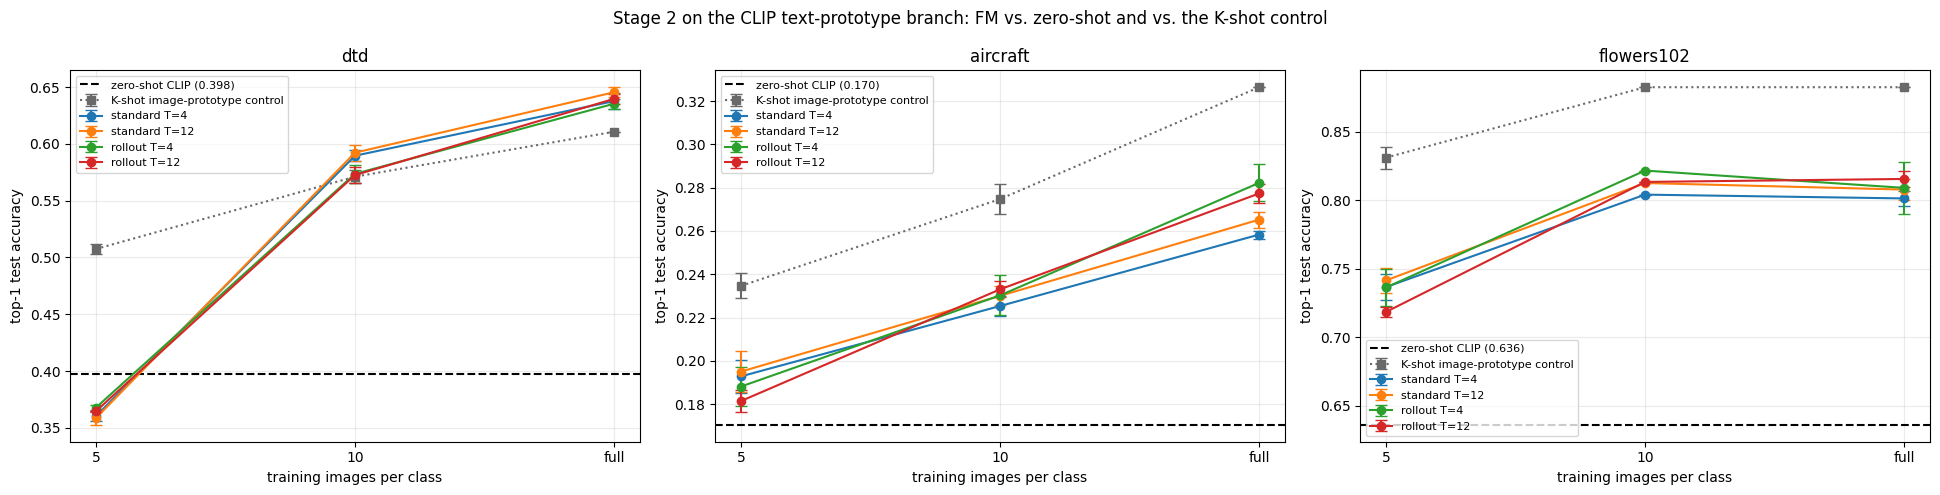

In [12]:
fm_summary = results_df.groupby(['dataset', 'shot', 'variant', 'T'], as_index=False).agg(
    mean_accuracy=('test_accuracy', 'mean'), std_accuracy=('test_accuracy', 'std'), runs=('test_accuracy', 'size'))

comparison = (fm_summary
              .merge(zero_shot[['dataset', 'zero_shot_accuracy']], on='dataset', how='left')
              .merge(control_summary, on=['dataset', 'shot'], how='left')
              .merge(subset_diagnostics[['dataset', 'shot', 'effective_repetitions']], on=['dataset', 'shot'], how='left'))
comparison['delta_vs_zero_shot'] = comparison['mean_accuracy'] - comparison['zero_shot_accuracy']
comparison['delta_vs_control'] = comparison['mean_accuracy'] - comparison['control_mean_accuracy']
comparison = comparison.sort_values(['dataset', 'shot', 'variant', 'T'])
comparison.to_csv(OUTPUT_ROOT / 'accuracy_summary_with_baselines.csv', index=False)
display(comparison.style.format({
    'mean_accuracy': '{:.4f}', 'std_accuracy': '{:.4f}', 'zero_shot_accuracy': '{:.4f}',
    'control_mean_accuracy': '{:.4f}', 'control_std_accuracy': '{:.4f}',
    'delta_vs_zero_shot': '{:+.4f}', 'delta_vs_control': '{:+.4f}'}))

shot_x = {'5': 0, '10': 1, 'full': 2}
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6.5 * len(DATASETS), 5), squeeze=False)
for ax, dataset_name in zip(axes.ravel(), DATASETS):
    zs = float(zero_shot.loc[zero_shot.dataset == dataset_name, 'zero_shot_accuracy'].iloc[0])
    ax.axhline(zs, color='black', linestyle='--', label=f'zero-shot CLIP ({zs:.3f})')
    ctl = control_summary[control_summary.dataset == dataset_name].copy()
    ctl['x'] = ctl.shot.map(shot_x); ctl = ctl.sort_values('x')
    ax.errorbar(ctl.x, ctl.control_mean_accuracy, yerr=ctl.control_std_accuracy.fillna(0),
                marker='s', capsize=4, color='dimgray', linestyle=':', label='K-shot image-prototype control')
    part = comparison[comparison.dataset == dataset_name].copy()
    part['x'] = part.shot.map(shot_x)
    for variant in ('standard', 'rollout'):
        for T in FM['T_values']:
            row = part[(part.variant == variant) & (part['T'] == T)].sort_values('x')
            ax.errorbar(row.x, row.mean_accuracy, yerr=row.std_accuracy.fillna(0), marker='o', capsize=4,
                        label=f'{variant} T={T}')
    ax.set(title=dataset_name, xticks=[0, 1, 2], xticklabels=['5', '10', 'full'],
           xlabel='training images per class', ylabel='top-1 test accuracy')
    ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.suptitle('Stage 2 on the CLIP text-prototype branch: FM vs. zero-shot and vs. the K-shot control')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'accuracy_vs_training_size.png', dpi=180, bbox_inches='tight'); plt.show()

## 13. Representative training curves

Seed 0 of the 10-shot setting, matching the convention used elsewhere in the project. Standard-FM loss (velocity MSE at a random `t`) and rolled-out loss (final-point MSE after a full `T`-step rollout) are different quantities on different scales — they share a log axis only to check what the PDF asks for, that both objectives train stably and reach a reasonable solution, not to compare their magnitudes.

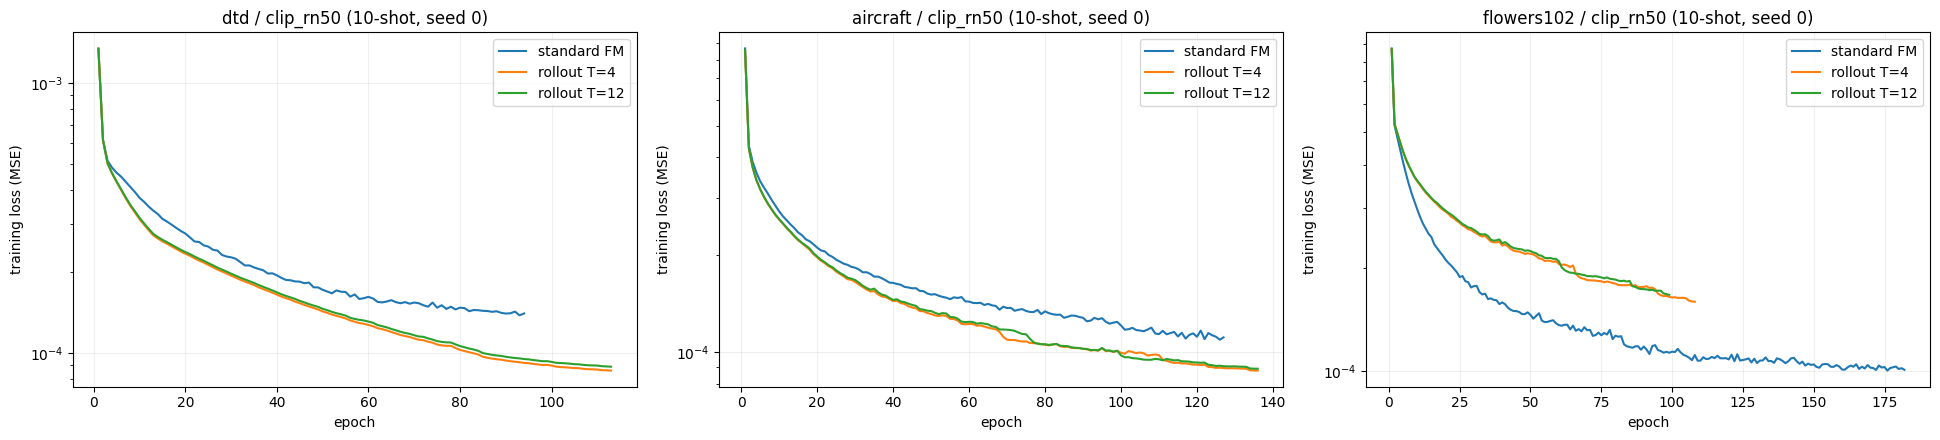

In [13]:
curve_series = [('standard', 'standard FM')] + [(f'rollout_T{T}', f'rollout T={T}') for T in FM['T_values']]
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6.5 * len(DATASETS), 4.5), squeeze=False)
for ax, dataset_name in zip(axes.ravel(), DATASETS):
    bundle = fm_histories[(dataset_name, '10', 0)]
    for mode_tag, label in curve_series:
        history = bundle.get(mode_tag)
        if not history:
            print(f'No training history for {dataset_name} / {mode_tag} (loaded from cache); skipping that curve.')
            continue
        h = pd.DataFrame(history)
        ax.plot(h.epoch, h.train_loss, label=label)
    ax.set(title=f'{dataset_name} / {ENCODER_TAG} (10-shot, seed 0)', xlabel='epoch',
           ylabel='training loss (MSE)', yscale='log')
    ax.legend(); ax.grid(alpha=.2)
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'training_curves.png', dpi=180, bbox_inches='tight'); plt.show()

## 14. Feature-space visualization: original vs. standard-FM vs. rolled-out-FM

Per the PDF, the projection is fit **jointly across all three views plus the text prototypes** — one PCA fit over the concatenation of original / standard-transported / rollout-transported embeddings and the selected prototypes — so the three panels share one coordinate frame and a point's movement between panels is directly comparable. `draw_three_views` also gives the three panels **shared axis limits**, since a joint fit that is then autoscaled per panel would rescale each view independently and hide the very contraction the figure exists to show.

Same 10 classes, up to 30 test examples per class, and the same `tab10` colors as Stage 1's CLIP feature plot, using the representative 10-shot / seed-0 networks at `T=12`. `fm_view_bank` caches the joint matrices so Section 15's t-SNE runs on the identical tensors instead of re-running the flow.

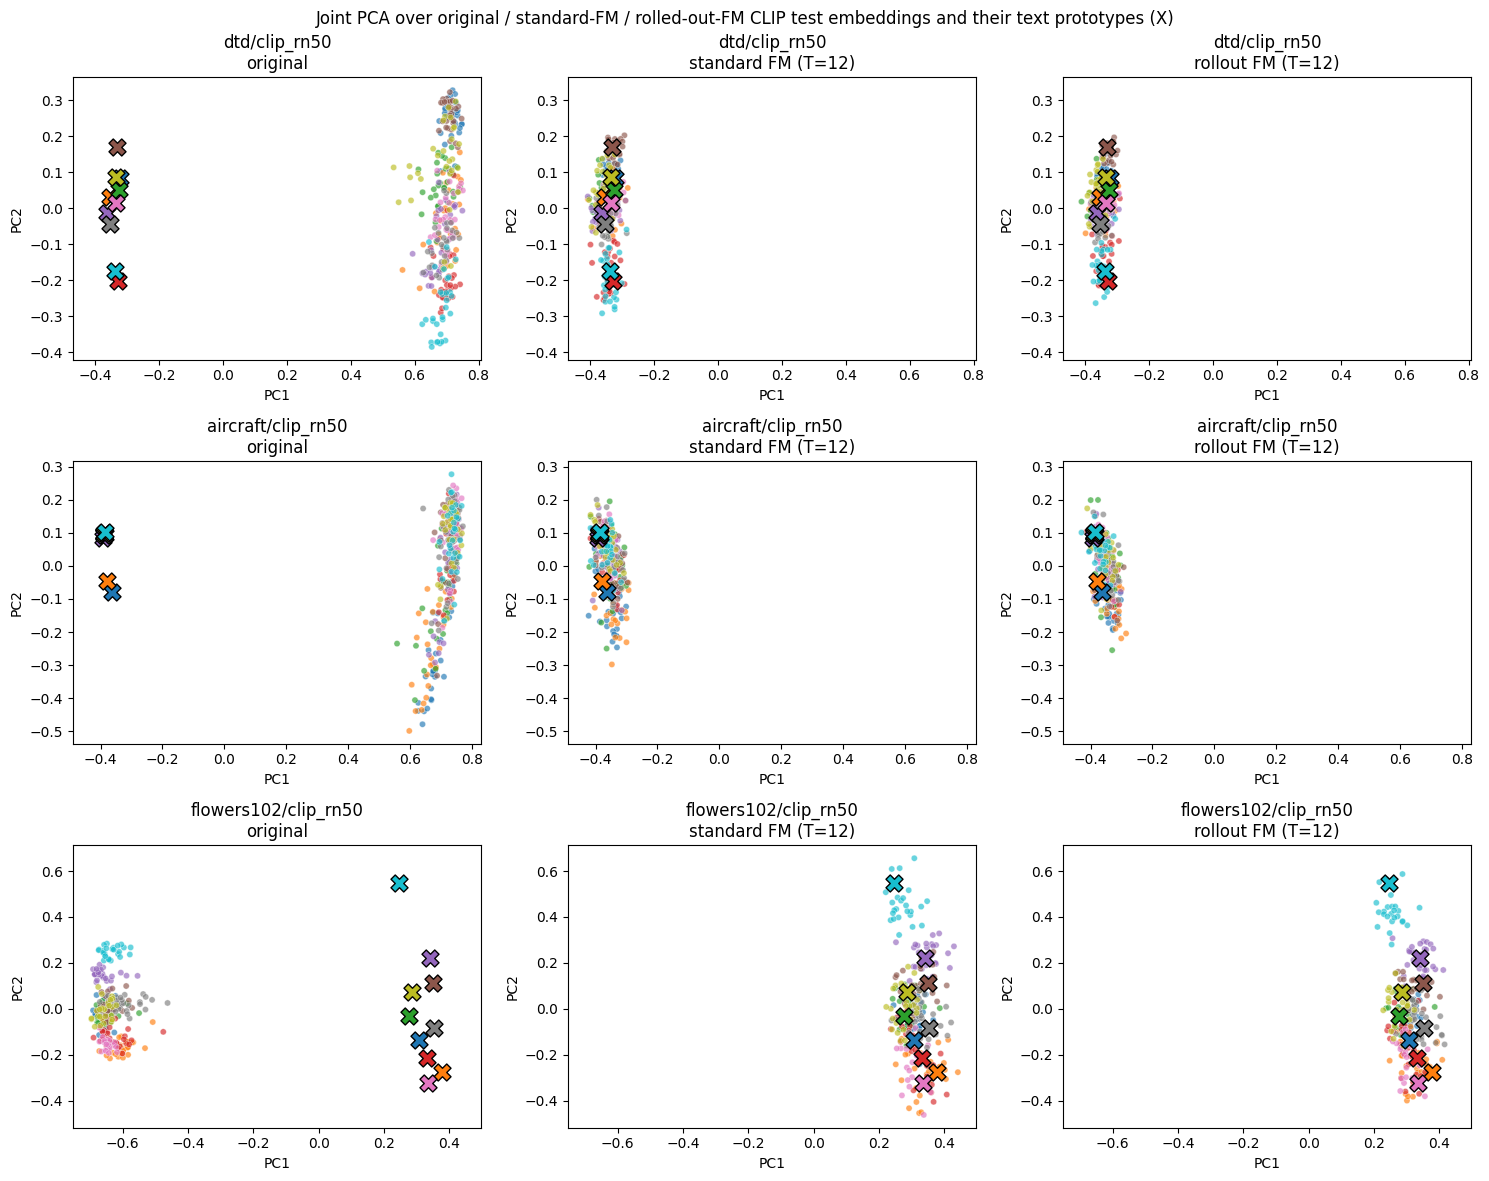

In [14]:
VIEW_TITLES = ['original', 'standard FM (T=12)', 'rollout FM (T=12)']

def draw_three_views(target_axes, xy, n, y, n_classes, title_prefix, axis_labels):
    """Draw the three compared views from one *jointly fit* 2-D embedding `xy` of the row-stacked
    [z | z_standard | z_rollout | text prototypes]. All three panels get the same xlim/ylim, so a point's
    displacement between panels is real movement in the shared projection, not per-panel autoscaling."""
    palette = sns.color_palette('tab10', n_classes)
    pad = 0.05 * np.ptp(xy, axis=0)
    xlim = (xy[:, 0].min() - pad[0], xy[:, 0].max() + pad[0])
    ylim = (xy[:, 1].min() - pad[1], xy[:, 1].max() + pad[1])
    proto_xy = xy[3 * n:]
    for k, view_title in enumerate(VIEW_TITLES):
        ax, pts = target_axes[k], xy[k * n:(k + 1) * n]
        sns.scatterplot(x=pts[:, 0], y=pts[:, 1], hue=y, palette=palette, s=20, alpha=.65, ax=ax, legend=False)
        for c_idx in range(n_classes):
            ax.scatter(proto_xy[c_idx, 0], proto_xy[c_idx, 1], color=palette[c_idx], marker='X', s=150, edgecolors='black')
        ax.set(title=f'{title_prefix}\n{view_title}', xlabel=axis_labels[0], ylabel=axis_labels[1], xlim=xlim, ylim=ylim)

fm_view_bank = {}
fig, axes = plt.subplots(len(DATASETS), 3, figsize=(15, 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    bank = feature_bank[dataset_name]['test']
    labels = bank['labels'].numpy()
    selected_classes = np.arange(10)
    selected_idx = np.concatenate([np.flatnonzero(labels == c)[:30] for c in selected_classes])
    z = F.normalize(bank['features'][selected_idx].float(), dim=1).to(DEVICE)
    y = labels[selected_idx]
    prototypes = text_bank[dataset_name].to(DEVICE)
    standard_net = load_trained_network(dataset_name, '10', 0, 0, 'standard', z.shape[1])
    rollout_net = load_trained_network(dataset_name, '10', 0, 0, 'rollout_T12', z.shape[1])
    with torch.no_grad():
        z_standard = euler_rollout(standard_net, z, 12)
        z_rollout = euler_rollout(rollout_net, z, 12)
    joint = torch.cat([z, z_standard, z_rollout, prototypes[selected_classes]]).cpu().numpy()
    fm_view_bank[dataset_name] = dict(joint=joint, y=y, n=len(z), n_classes=len(selected_classes))
    draw_three_views(axes[i], PCA(n_components=2).fit_transform(joint), len(z), y, len(selected_classes),
                     f'{dataset_name}/{ENCODER_TAG}', ('PC1', 'PC2'))
fig.suptitle('Joint PCA over original / standard-FM / rolled-out-FM CLIP test embeddings and their text prototypes (X)')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'feature_space_comparison.png', dpi=180, bbox_inches='tight'); plt.show()

## 15. The same comparison under a joint t-SNE

The PDF allows PCA **or** t-SNE, and Stage 1's CLIP notebook already shows its embeddings under both, so this repeats Section 14 with t-SNE on exactly the same cached matrices, the same classes, examples and colors — the figures differ only in the projection. One t-SNE is fit per dataset over the full `[z | z_standard | z_rollout | prototypes]` stack, never per panel, so all three views and the prototypes share one embedding.

**Read this qualitatively and read Section 14 for anything geometric.** t-SNE normalizes local density, so it deliberately re-expands the tightly contracted post-FM clusters: the visual shrinkage toward each text prototype will look far milder here than it is numerically. Cluster separation and which prototype a class sits on read well here; distances and the near-collapse the flow actually produces read well in PCA. That is also why Section 16's trajectories stay on PCA.

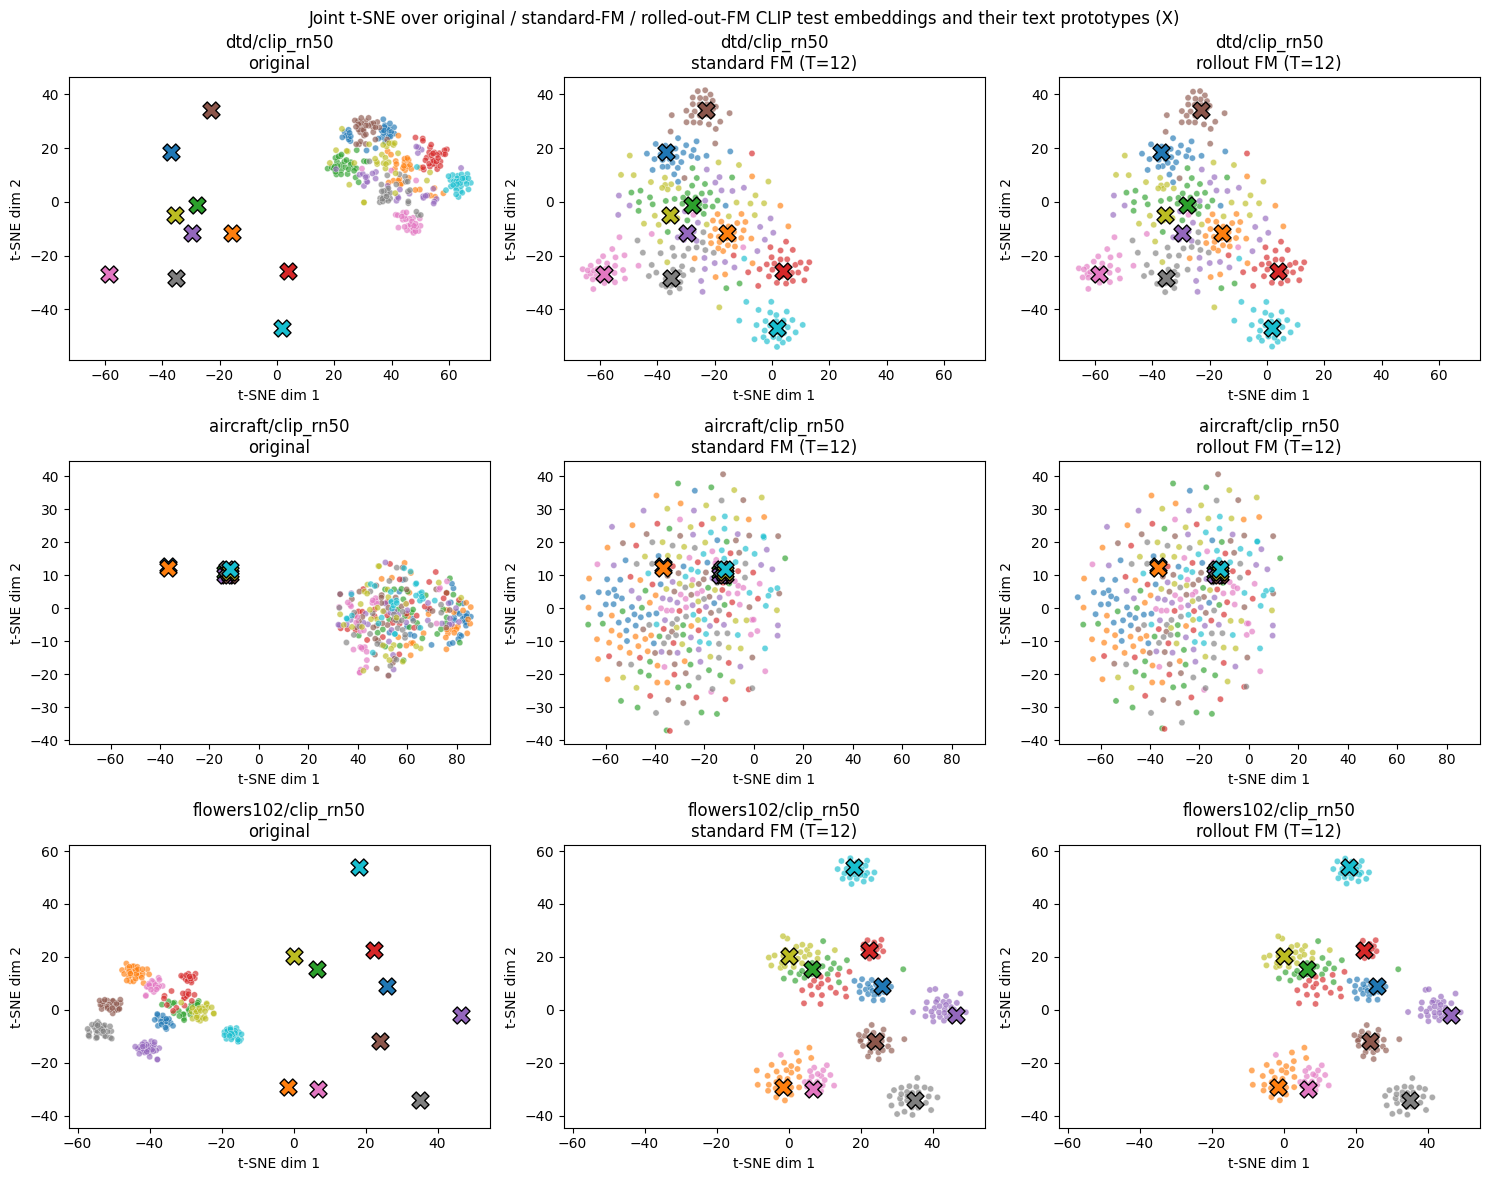

In [15]:
fig, axes = plt.subplots(len(DATASETS), 3, figsize=(15, 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    view = fm_view_bank[dataset_name]
    joint, y, n, n_classes = view['joint'], view['y'], view['n'], view['n_classes']
    perplexity = min(30, max(5, len(joint) // 3 - 1))
    xy = TSNE(n_components=2, perplexity=perplexity, init='pca', random_state=0).fit_transform(joint)
    draw_three_views(axes[i], xy, n, y, n_classes, f'{dataset_name}/{ENCODER_TAG}', ('t-SNE dim 1', 't-SNE dim 2'))
fig.suptitle('Joint t-SNE over original / standard-FM / rolled-out-FM CLIP test embeddings and their text prototypes (X)')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'feature_space_comparison_tsne.png', dpi=180, bbox_inches='tight'); plt.show()

## 16. Flow trajectories

For 3 representative test examples per dataset (one per class, first 3 classes), the intermediate Euler states `ẑ_0 … ẑ_12` from the standard-FM network are plotted with the original embedding, the final transported embedding, and the target text prototype, in one PCA fit jointly over that trajectory plus its prototype. PCA rather than t-SNE, per the PDF, because the projected path has to stay interpretable as a path.

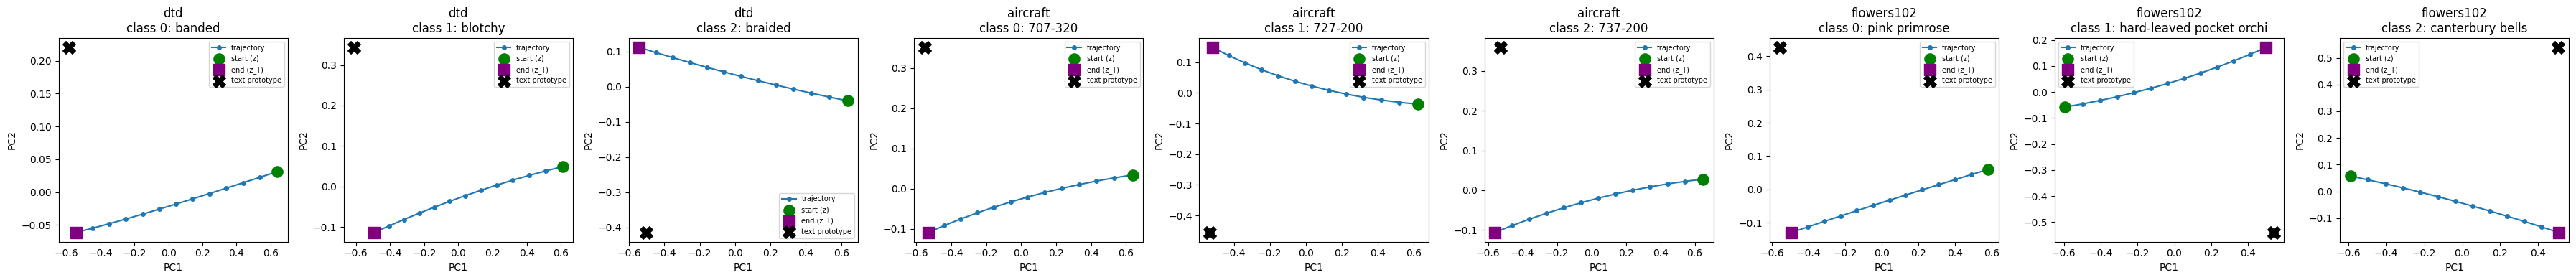

In [16]:
fig, axes = plt.subplots(1, len(DATASETS) * 3, figsize=(4 * len(DATASETS) * 3, 4), squeeze=False)
axes = axes.ravel(); col = 0
for dataset_name in DATASETS:
    bank = feature_bank[dataset_name]['test']
    labels = bank['labels'].numpy()
    prototypes = text_bank[dataset_name].to(DEVICE)
    net = load_trained_network(dataset_name, '10', 0, 0, 'standard', prototypes.shape[1])
    for c in np.arange(3):
        idx = int(np.flatnonzero(labels == c)[0])
        z0 = F.normalize(bank['features'][idx:idx + 1].float(), dim=1).to(DEVICE)
        with torch.no_grad():
            _, trajectory = euler_rollout(net, z0, 12, return_trajectory=True)
        traj = torch.cat(trajectory).cpu().numpy()
        proto = prototypes[c:c + 1].cpu().numpy()
        xy = PCA(n_components=2).fit_transform(np.concatenate([traj, proto]))
        ax = axes[col]; col += 1
        ax.plot(xy[:-1, 0], xy[:-1, 1], '-o', color='tab:blue', markersize=4, label='trajectory')
        ax.scatter(xy[0, 0], xy[0, 1], color='green', s=120, zorder=5, label='start (z)')
        ax.scatter(xy[-2, 0], xy[-2, 1], color='purple', s=120, marker='s', zorder=5, label='end (z_T)')
        ax.scatter(xy[-1, 0], xy[-1, 1], color='black', s=160, marker='X', zorder=5, label='text prototype')
        ax.set(title=f'{dataset_name}\nclass {c}: {bank["classes"][c][:24]}', xlabel='PC1', ylabel='PC2')
        ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'flow_trajectories.png', dpi=180, bbox_inches='tight'); plt.show()

## 17. Optional extension A: the flow in reverse

The PDF's first optional extension, and the more interesting one on this branch: start from each **text** prototype at `t=1` and integrate the same learned field backward toward `t=0`, to see whether the reverse-transported prompt lands inside its class's real image-embedding cloud. That is a direct probe of how far apart CLIP's text and image modalities sit, and whether the FM layer learned a usable bridge between them.

The **recovery rate** makes it quantitative: for each class, does the reverse-flowed text prototype land nearest to its *own* class's mean test image embedding? The untouched forward text prototype is the **pre-transport reference** — where the prompt sits before the field touches it.

**The reference is not a ceiling, and on this branch the reverse pass clearly beats it.** That phrasing was wrong in an earlier version of this notebook and the measured numbers contradict it: reverse recovery reaches 1.000 / 0.750 / 1.000 against forward references of 0.553 / 0.250 / 0.745. The reason is specific to this branch and worth stating plainly. A CLIP text prototype does not live in the middle of its class's image cloud — the two modalities occupy different regions of the joint space, which is exactly the modality gap zero-shot CLIP suffers from. Integrating backward through a field trained to carry *images to text prototypes* therefore moves the text prototype **toward** the visual cloud, and it can easily end up a better match to the class's image mean than the prompt it started from. So the reverse experiment on this branch measures something real: how much of the modality gap the learned field can undo.

On the image-prototype branch (`04_flow_matching.ipynb`) no such improvement is possible, because the forward prototype is *already* the mean of that class's images — there the reference genuinely is close to a ceiling, and reverse recovery only ever degrades. The contrast between the two branches is the finding, not a discrepancy.

Recovery is a discrete nearest-centroid test, so it saturates and cannot distinguish "just barely closest" from "landed on top of it". Two continuous quantities are reported alongside it — `cos(p̃_c, μ_c)` and `‖p̃_c − μ_c‖` against the class image mean — so the section answers both *did class identity recover* and *did the prototype actually move closer to its visual class*.

Two caveats, unchanged from the image branch. The backward pass evaluates the field at `t` in {1, 1−1/T, ..., 1/T} while the forward pass uses {0, ..., 1−1/T}, so it is **not** the exact inverse even for a perfect field. And the forward flow is a deliberate contraction, so it is not invertible in principle — the reverse pass recovers a plausible pre-image, not the original point. Read this as a check on how well-behaved the learned field is, never as a demonstration of invertibility.

In [17]:
def euler_rollout_reverse(v_theta, z0, T, return_trajectory=False):
    """Integrate the learned field backward from t=1 toward t=0. Mirrors `euler_rollout`: same step
    size and one network evaluation per step, but decreasing time and a subtracted update."""
    z = z0
    trajectory = [z0.detach().clone()] if return_trajectory else None
    for k in range(T):
        t = torch.full((z.shape[0],), 1.0 - k / T, device=z.device, dtype=z.dtype)
        z = z - (1.0 / T) * v_theta(z, t)
        if return_trajectory: trajectory.append(z.detach().clone())
    return (z, trajectory) if return_trajectory else z

def class_mean_features(x, y, n_classes):
    """Unit-norm mean test image embedding per class - the empirical cloud centre a reverse-flowed
    text prototype should land nearest to if the learned field is well behaved."""
    means = torch.stack([x[y == c].mean(0) if bool((y == c).any())
                         else torch.zeros(x.shape[1], device=x.device) for c in range(n_classes)])
    return F.normalize(means, dim=1)

def alignment_to_class_means(prototypes, means):
    """Continuous companions to the discrete recovery rate: recovery saturates and cannot tell
    'just barely closest' from 'landed on top of it', so also report how close the prototype
    actually is to its own class mean."""
    P = F.normalize(prototypes, dim=1)
    return float((P * means).sum(1).mean().item()), float((P - means).norm(dim=1).mean().item())

REVERSE_T = 12
reverse_rows, reverse_views = [], {}
for dataset_name in DATASETS:
    bank = feature_bank[dataset_name]['test']
    x = F.normalize(bank['features'].float(), dim=1).to(DEVICE)
    y = bank['labels'].long().to(DEVICE)
    prototypes = text_bank[dataset_name].to(DEVICE)
    n_classes = prototypes.shape[0]
    net = load_trained_network(dataset_name, '10', 0, 0, 'standard', x.shape[1])
    with torch.no_grad():
        reversed_protos, reverse_traj = euler_rollout_reverse(net, prototypes, REVERSE_T, return_trajectory=True)
    means = class_mean_features(x, y, n_classes)
    target = torch.arange(n_classes, device=DEVICE)
    forward_hit = (F.normalize(prototypes, dim=1) @ means.T).argmax(1) == target
    reverse_hit = (F.normalize(reversed_protos, dim=1) @ means.T).argmax(1) == target
    moved = 1 - (F.normalize(reversed_protos, dim=1) * F.normalize(prototypes, dim=1)).sum(1)
    fwd_cos, fwd_dist = alignment_to_class_means(prototypes, means)
    rev_cos, rev_dist = alignment_to_class_means(reversed_protos, means)
    reverse_rows.append(dict(dataset=dataset_name, classes=n_classes,
                             forward_recovery=forward_hit.float().mean().item(),
                             reverse_recovery=reverse_hit.float().mean().item(),
                             forward_cos_to_class_mean=fwd_cos, reverse_cos_to_class_mean=rev_cos,
                             forward_dist_to_class_mean=fwd_dist, reverse_dist_to_class_mean=rev_dist,
                             cos_gain=rev_cos - fwd_cos,
                             mean_cosine_distance_moved=moved.mean().item()))
    reverse_views[dataset_name] = dict(traj=[s.cpu() for s in reverse_traj],
                                       x=x.cpu(), y=y.cpu())
reverse_summary = pd.DataFrame(reverse_rows)
reverse_summary.to_csv(OUTPUT_ROOT / 'reverse_flow_recovery.csv', index=False)
print('Recovery rate = fraction of classes whose (reverse-flowed) text prototype is nearest to its OWN')
print('class mean test embedding. "forward" is the untouched text prototype: the PRE-TRANSPORT')
print('REFERENCE, not a ceiling - on this branch the reverse pass is expected to exceed it, because a')
print('text prototype does not start out inside its own image cloud (the CLIP modality gap) and the')
print('backward flow carries it toward that cloud. cos_gain > 0 quantifies that movement.')
display(reverse_summary.style.format({
    'forward_recovery': '{:.3f}', 'reverse_recovery': '{:.3f}',
    'forward_cos_to_class_mean': '{:.4f}', 'reverse_cos_to_class_mean': '{:.4f}',
    'forward_dist_to_class_mean': '{:.4f}', 'reverse_dist_to_class_mean': '{:.4f}',
    'cos_gain': '{:+.4f}', 'mean_cosine_distance_moved': '{:.4f}'}))

Recovery rate = fraction of classes whose (reverse-flowed) text prototype is nearest to its OWN
class mean test embedding. "forward" is the untouched text prototype: the PRE-TRANSPORT
REFERENCE, not a ceiling - on this branch the reverse pass is expected to exceed it, because a
text prototype does not start out inside its own image cloud (the CLIP modality gap) and the
backward flow carries it toward that cloud. cos_gain > 0 quantifies that movement.


,dataset,classes,forward_recovery,reverse_recovery,forward_cos_to_class_mean,reverse_cos_to_class_mean,forward_dist_to_class_mean,reverse_dist_to_class_mean,cos_gain,mean_cosine_distance_moved
0,dtd,47,0.553,1.000,0.2705,0.9604,1.2078,0.2785,+0.6899,0.7175
1,aircraft,100,0.250,0.750,0.2764,0.9741,1.2029,0.2256,+0.6977,0.6974
2,flowers102,102,0.745,1.000,0.2886,0.9859,1.1926,0.1658,+0.6973,0.6772


### 17b. Where the text prototypes go on the way back

The same reverse integration at five reverse times. The faint cloud is the real CLIP test embeddings (10 classes, up to 30 examples each) and the **P** markers are the text prototypes after that much backward integration. One PCA per row is fit jointly over the embeddings and every reverse state shown, and all five panels share axis limits, so movement across a row is real movement in one plane.

At `reverse t = 1` the P markers sit where the text prototypes actually live - typically off to one side of the image cloud, which *is* the CLIP modality gap made visible. Watching them move left to right shows how much of that gap the learned field closes.

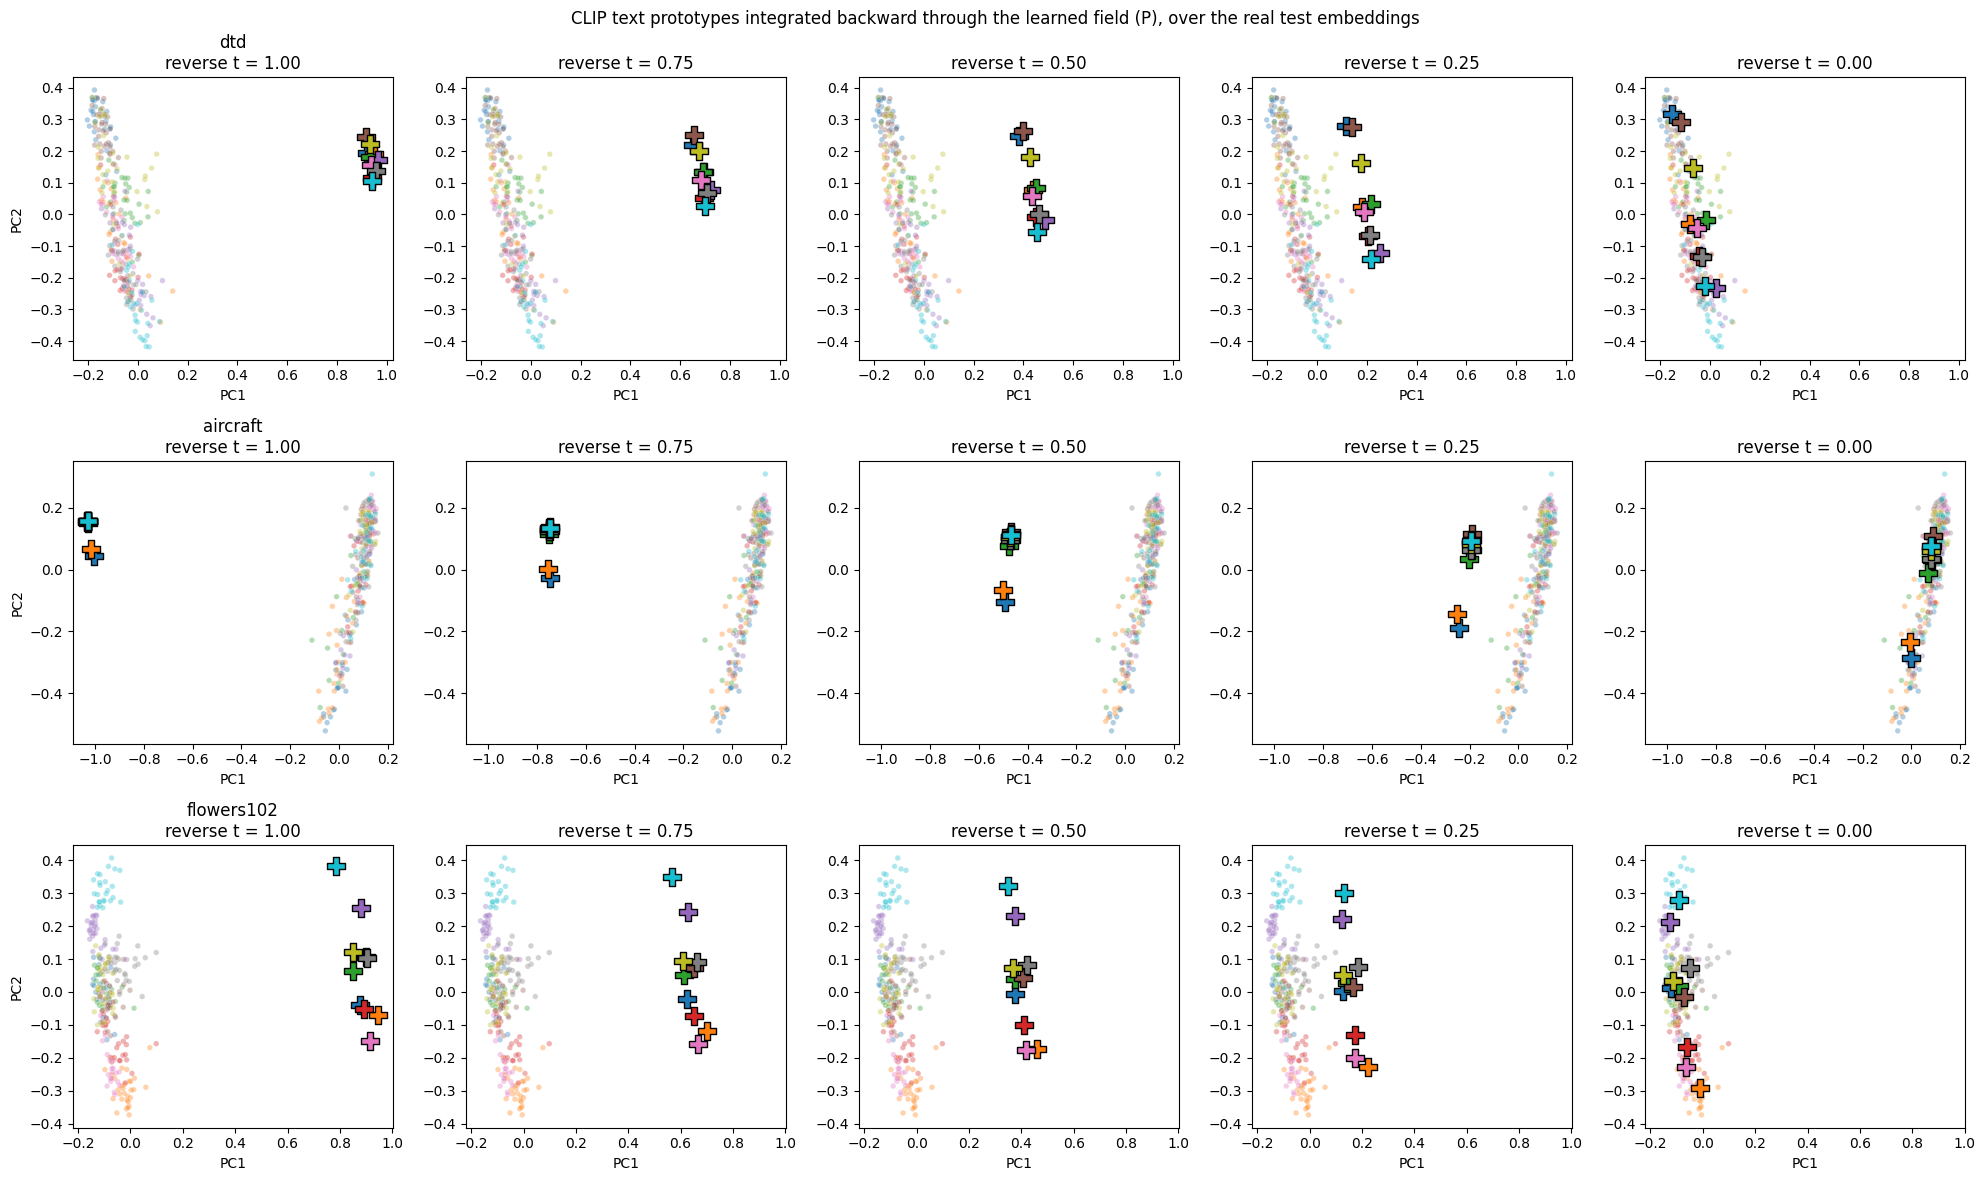

In [18]:
REVERSE_SNAPSHOTS = [0, REVERSE_T // 4, REVERSE_T // 2, 3 * REVERSE_T // 4, REVERSE_T]
fig, axes = plt.subplots(len(DATASETS), len(REVERSE_SNAPSHOTS),
                         figsize=(4 * len(REVERSE_SNAPSHOTS), 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    view = reverse_views[dataset_name]
    labels = view['y'].numpy()
    selected_classes = np.arange(10)
    sel = np.concatenate([np.flatnonzero(labels == c)[:30] for c in selected_classes])
    bg = view['x'][sel].numpy(); bg_y = labels[sel]
    states = [view['traj'][k][selected_classes].numpy() for k in REVERSE_SNAPSHOTS]
    pca = PCA(n_components=2).fit(np.concatenate([bg] + states))
    bg_xy = pca.transform(bg); state_xy = [pca.transform(s) for s in states]
    allxy = np.concatenate([bg_xy] + state_xy)
    pad = 0.05 * np.ptp(allxy, axis=0)
    xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
    ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])
    palette = sns.color_palette('tab10', 10)
    for j, (k, xy) in enumerate(zip(REVERSE_SNAPSHOTS, state_xy)):
        ax = axes[i, j]
        sns.scatterplot(x=bg_xy[:, 0], y=bg_xy[:, 1], hue=bg_y, palette=palette, s=16, alpha=.35,
                        ax=ax, legend=False)
        for c_idx in range(len(selected_classes)):
            ax.scatter(xy[c_idx, 0], xy[c_idx, 1], color=palette[c_idx], marker='P', s=170,
                       edgecolors='black', zorder=5)
        header = f'{dataset_name}\n' if j == 0 else ''
        ax.set(title=f'{header}reverse t = {1 - k / REVERSE_T:.2f}', xlabel='PC1',
               ylabel='PC2' if j == 0 else '', xlim=xlim, ylim=ylim)
fig.suptitle('CLIP text prototypes integrated backward through the learned field (P), over the real test embeddings')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'reverse_flow.png', dpi=180, bbox_inches='tight'); plt.show()

## 18. Optional extension B: samples and prototypes at intermediate flow times

The PDF's second optional extension. Instead of looking only at `t=0` and `t=1`, measure what the flow is doing at **every** Euler state.

On this branch the anchor at `t=0` is especially clean: the state at `t=0` is the untouched CLIP image embedding, and classifying it by cosine similarity to the text prototypes **is zero-shot CLIP**. So the accuracy-versus-`t` curve starts exactly at the Stage 1 zero-shot number and ends at the FM result - the cell asserts the first against the baseline recomputed in Section 7. The whole "how far does supervised transport get us from zero-shot" question is that one curve.

Three further quantities track the mechanism rather than the outcome: cosine similarity to the true text prototype and L2 distance to it (is the embedding actually crossing the modality gap toward its target?) and the **margin**, `cos(z, t_true) - max over other classes of cos(z, t_c)` (is it crossing toward the *right* target, or merely contracting everything?).

Representative setting: 10-shot, seed 0, `T=12`. Metrics are computed over the complete test split; chunking only bounds memory.

In [19]:
def flow_metrics_over_time(net, x, y, prototypes, T, chunk=2048):
    """Per-step statistics of every intermediate Euler state, over the full test split.

    Uses the shared `euler_rollout`, so these are exactly the states inference produces - chunking
    bounds memory only. Row k=0 is the untouched CLIP embedding, so its accuracy is the zero-shot
    CLIP baseline by construction; row k=T is the reported FM result."""
    net.eval()
    P = F.normalize(prototypes, dim=1)
    n_steps = T + 1
    correct, margin = np.zeros(n_steps), np.zeros(n_steps)
    cos_true, dist = np.zeros(n_steps), np.zeros(n_steps)
    with torch.no_grad():
        for s in range(0, len(x), chunk):
            xb, yb = x[s:s + chunk], y[s:s + chunk]
            _, traj = euler_rollout(net, xb, T, return_trajectory=True)
            for k, z in enumerate(traj):
                scores = F.normalize(z, dim=1) @ P.T
                true_score = scores.gather(1, yb.view(-1, 1)).squeeze(1)
                masked = scores.clone(); masked.scatter_(1, yb.view(-1, 1), float('-inf'))
                correct[k] += float((scores.argmax(1) == yb).sum().item())
                margin[k] += float((true_score - masked.max(1).values).sum().item())
                cos_true[k] += float(true_score.sum().item())
                dist[k] += float((z - prototypes[yb]).norm(dim=1).sum().item())
    n = len(x)
    return pd.DataFrame(dict(step=np.arange(n_steps), t=np.arange(n_steps) / T,
                             accuracy=correct / n, margin=margin / n,
                             cosine_to_true_prototype=cos_true / n,
                             distance_to_true_prototype=dist / n))

INTERMEDIATE_T, INTERMEDIATE_SHOT, INTERMEDIATE_SEED = 12, '10', 0
INTERMEDIATE_MODES = [('standard', 'standard FM'),
                      (f'rollout_T{INTERMEDIATE_T}', f'rolled-out FM (T={INTERMEDIATE_T})')]

flow_time_curves, rows = {}, []
for dataset_name in DATASETS:
    bank = feature_bank[dataset_name]['test']
    x = F.normalize(bank['features'].float(), dim=1).to(DEVICE)
    y = bank['labels'].long().to(DEVICE)
    prototypes = text_bank[dataset_name].to(DEVICE)
    for mode_tag, label in INTERMEDIATE_MODES:
        net = load_trained_network(dataset_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED, 0,
                                   mode_tag, x.shape[1])
        curve = flow_metrics_over_time(net, x, y, prototypes, INTERMEDIATE_T)
        flow_time_curves[(dataset_name, mode_tag)] = curve
        rows.append(dict(dataset=dataset_name, model=label,
                         acc_t0=curve.accuracy.iloc[0], acc_t1=curve.accuracy.iloc[-1],
                         gain=curve.accuracy.iloc[-1] - curve.accuracy.iloc[0],
                         best_t=float(curve.t[curve.accuracy.idxmax()]), best_acc=curve.accuracy.max(),
                         margin_t0=curve.margin.iloc[0], margin_t1=curve.margin.iloc[-1],
                         cos_t0=curve.cosine_to_true_prototype.iloc[0],
                         cos_t1=curve.cosine_to_true_prototype.iloc[-1]))
    # t=0 is the untouched embedding classified against the text prototypes, i.e. zero-shot CLIP.
    zs = float(zero_shot.loc[zero_shot.dataset == dataset_name, 'zero_shot_accuracy'].iloc[0])
    drift = abs(flow_time_curves[(dataset_name, 'standard')].accuracy.iloc[0] - zs)
    assert drift < 1e-6, (f'{dataset_name}: t=0 accuracy differs from the zero-shot baseline by '
                          f'{drift:.2e}; the curve is not anchored to the baseline it claims to start from.')

flow_time_summary = pd.DataFrame(rows)
flow_time_summary.to_csv(OUTPUT_ROOT / 'intermediate_flow_time_metrics.csv', index=False)
print('Verified: t=0 accuracy equals the zero-shot CLIP baseline for every dataset.')
display(flow_time_summary.style.format({c: '{:.4f}' for c in
        ['acc_t0', 'acc_t1', 'gain', 'best_t', 'best_acc', 'margin_t0', 'margin_t1', 'cos_t0', 'cos_t1']}))

Verified: t=0 accuracy equals the zero-shot CLIP baseline for every dataset.


,dataset,model,acc_t0,acc_t1,gain,best_t,best_acc,margin_t0,margin_t1,cos_t0,cos_t1
0,dtd,standard FM,0.3979,0.5968,0.1989,0.7500,0.6011,-0.0033,0.0095,0.2292,0.8914
1,dtd,rolled-out FM (T=12),0.3979,0.5681,0.1702,0.5833,0.5941,-0.0033,0.0071,0.2292,0.9066
2,aircraft,standard FM,0.1704,0.2325,0.0621,0.6667,0.2418,-0.0121,-0.0195,0.2451,0.8746
3,aircraft,rolled-out FM (T=12),0.1704,0.2367,0.0663,0.5833,0.2637,-0.0121,-0.0186,0.2451,0.8933
4,flowers102,standard FM,0.6360,0.8125,0.1765,0.7500,0.8157,0.0064,0.0558,0.2682,0.8275
5,flowers102,rolled-out FM (T=12),0.6360,0.8133,0.1773,0.5833,0.8551,0.0064,0.0527,0.2682,0.8418


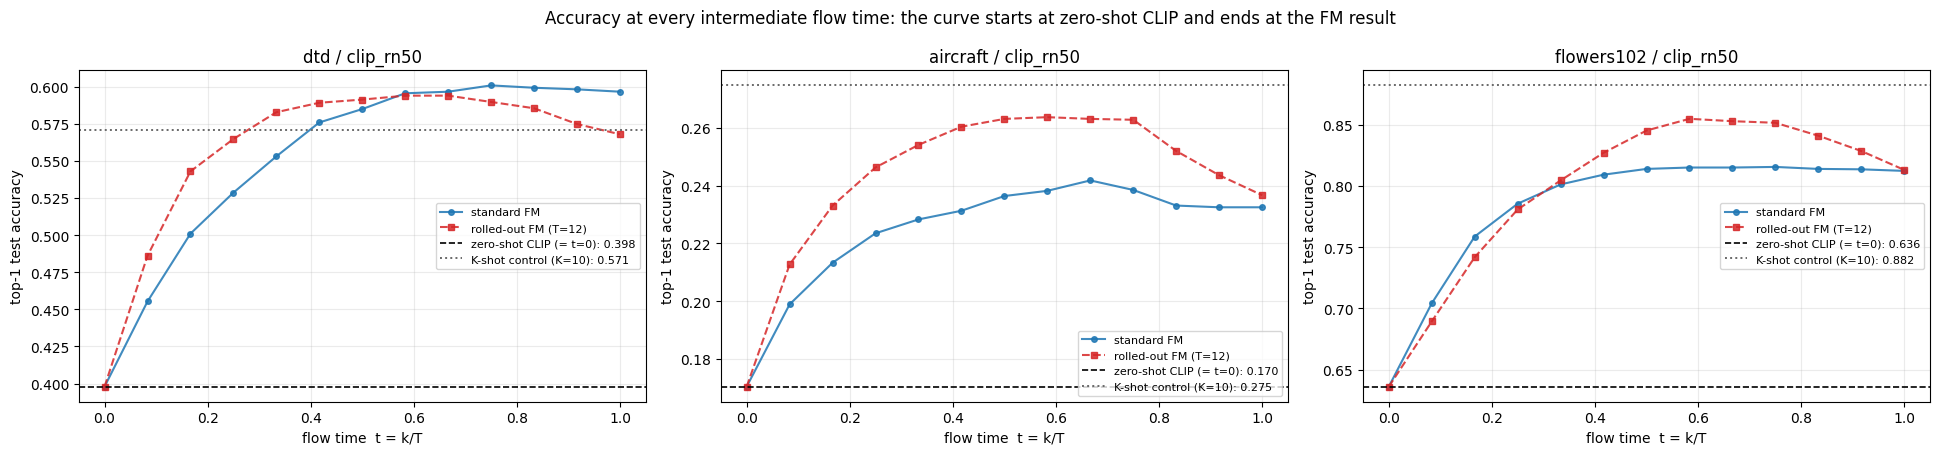

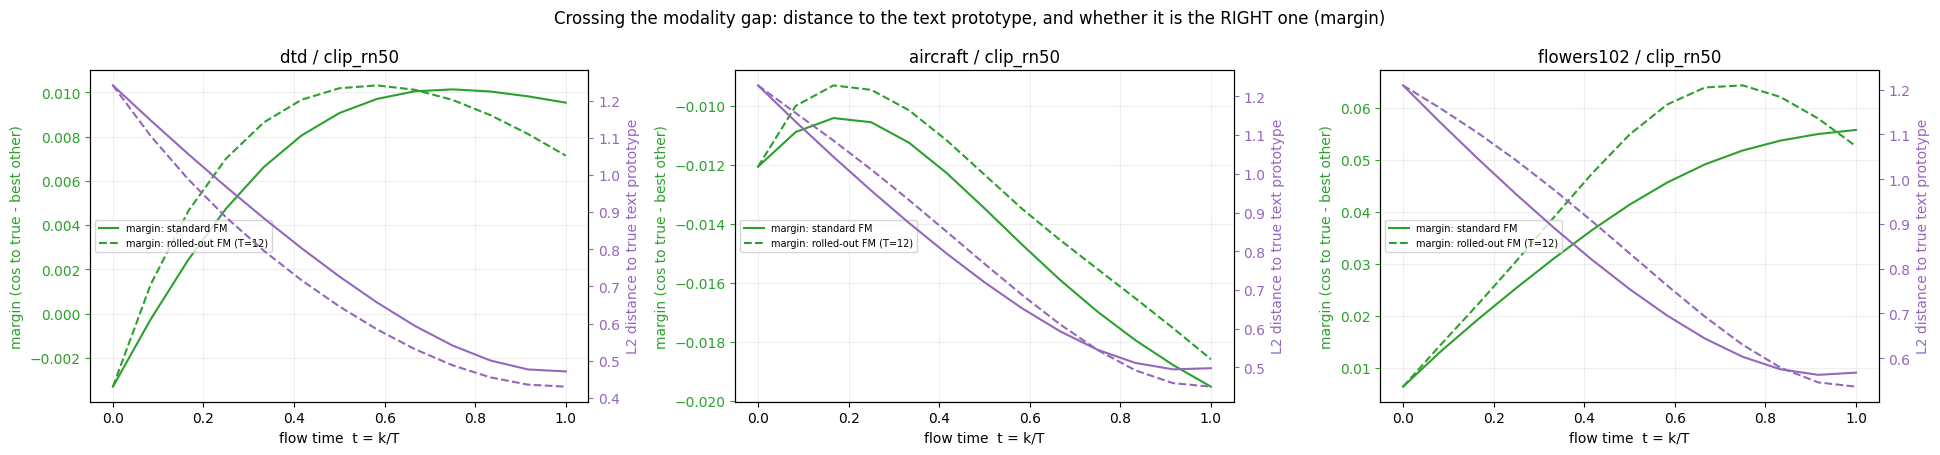

In [20]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6.5 * len(DATASETS), 4.6), squeeze=False)
for ax, dataset_name in zip(axes.ravel(), DATASETS):
    for (mode_tag, label), (color, style, marker) in zip(
            INTERMEDIATE_MODES, [('tab:blue', '-', 'o'), ('tab:red', '--', 's')]):
        c = flow_time_curves[(dataset_name, mode_tag)]
        ax.plot(c.t, c.accuracy, style, marker=marker, ms=4, color=color, label=label, alpha=.85)
    base = flow_time_curves[(dataset_name, 'standard')].accuracy.iloc[0]
    ax.axhline(base, color='black', ls='--', lw=1.2, label=f'zero-shot CLIP (= t=0): {base:.3f}')
    ctl = control_summary[(control_summary.dataset == dataset_name) &
                          (control_summary.shot == INTERMEDIATE_SHOT)]
    if len(ctl):
        v = float(ctl.control_mean_accuracy.iloc[0])
        ax.axhline(v, color='dimgray', ls=':', lw=1.4, label=f'K-shot control (K={INTERMEDIATE_SHOT}): {v:.3f}')
    ax.set(title=f'{dataset_name} / {ENCODER_TAG}', xlabel='flow time  t = k/T', ylabel='top-1 test accuracy')
    ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.suptitle('Accuracy at every intermediate flow time: the curve starts at zero-shot CLIP and ends at the FM result')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'accuracy_vs_flow_time.png', dpi=180, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6.5 * len(DATASETS), 4.6), squeeze=False)
for ax, dataset_name in zip(axes.ravel(), DATASETS):
    twin = ax.twinx()
    for (mode_tag, label), style in zip(INTERMEDIATE_MODES, ['-', '--']):
        c = flow_time_curves[(dataset_name, mode_tag)]
        ax.plot(c.t, c.margin, style, color='tab:green', label=f'margin: {label}')
        twin.plot(c.t, c.distance_to_true_prototype, style, color='tab:purple', label=f'distance: {label}')
    ax.set(title=f'{dataset_name} / {ENCODER_TAG}', xlabel='flow time  t = k/T')
    ax.set_ylabel('margin (cos to true - best other)', color='tab:green')
    twin.set_ylabel('L2 distance to true text prototype', color='tab:purple')
    ax.tick_params(axis='y', colors='tab:green'); twin.tick_params(axis='y', colors='tab:purple')
    ax.grid(alpha=.2); ax.legend(fontsize=7, loc='center left')
fig.suptitle('Crossing the modality gap: distance to the text prototype, and whether it is the RIGHT one (margin)')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'margin_and_distance_vs_flow_time.png', dpi=180, bbox_inches='tight'); plt.show()

### 18b. The embedding cloud at intermediate flow times

The same intermediate states, shown rather than measured. Each row is one dataset, once per training objective; columns are `t = 0, 1/4, 1/2, 3/4, 1`. One PCA per row is fit jointly over every snapshot plus the text prototypes, and all five panels share axis limits.

On this branch the first column shows the **modality gap** directly: the image embeddings sit in one region and the text prototypes (X) in another. Following the row left to right shows the learned transport carrying the image cloud across that gap onto the text prototypes.

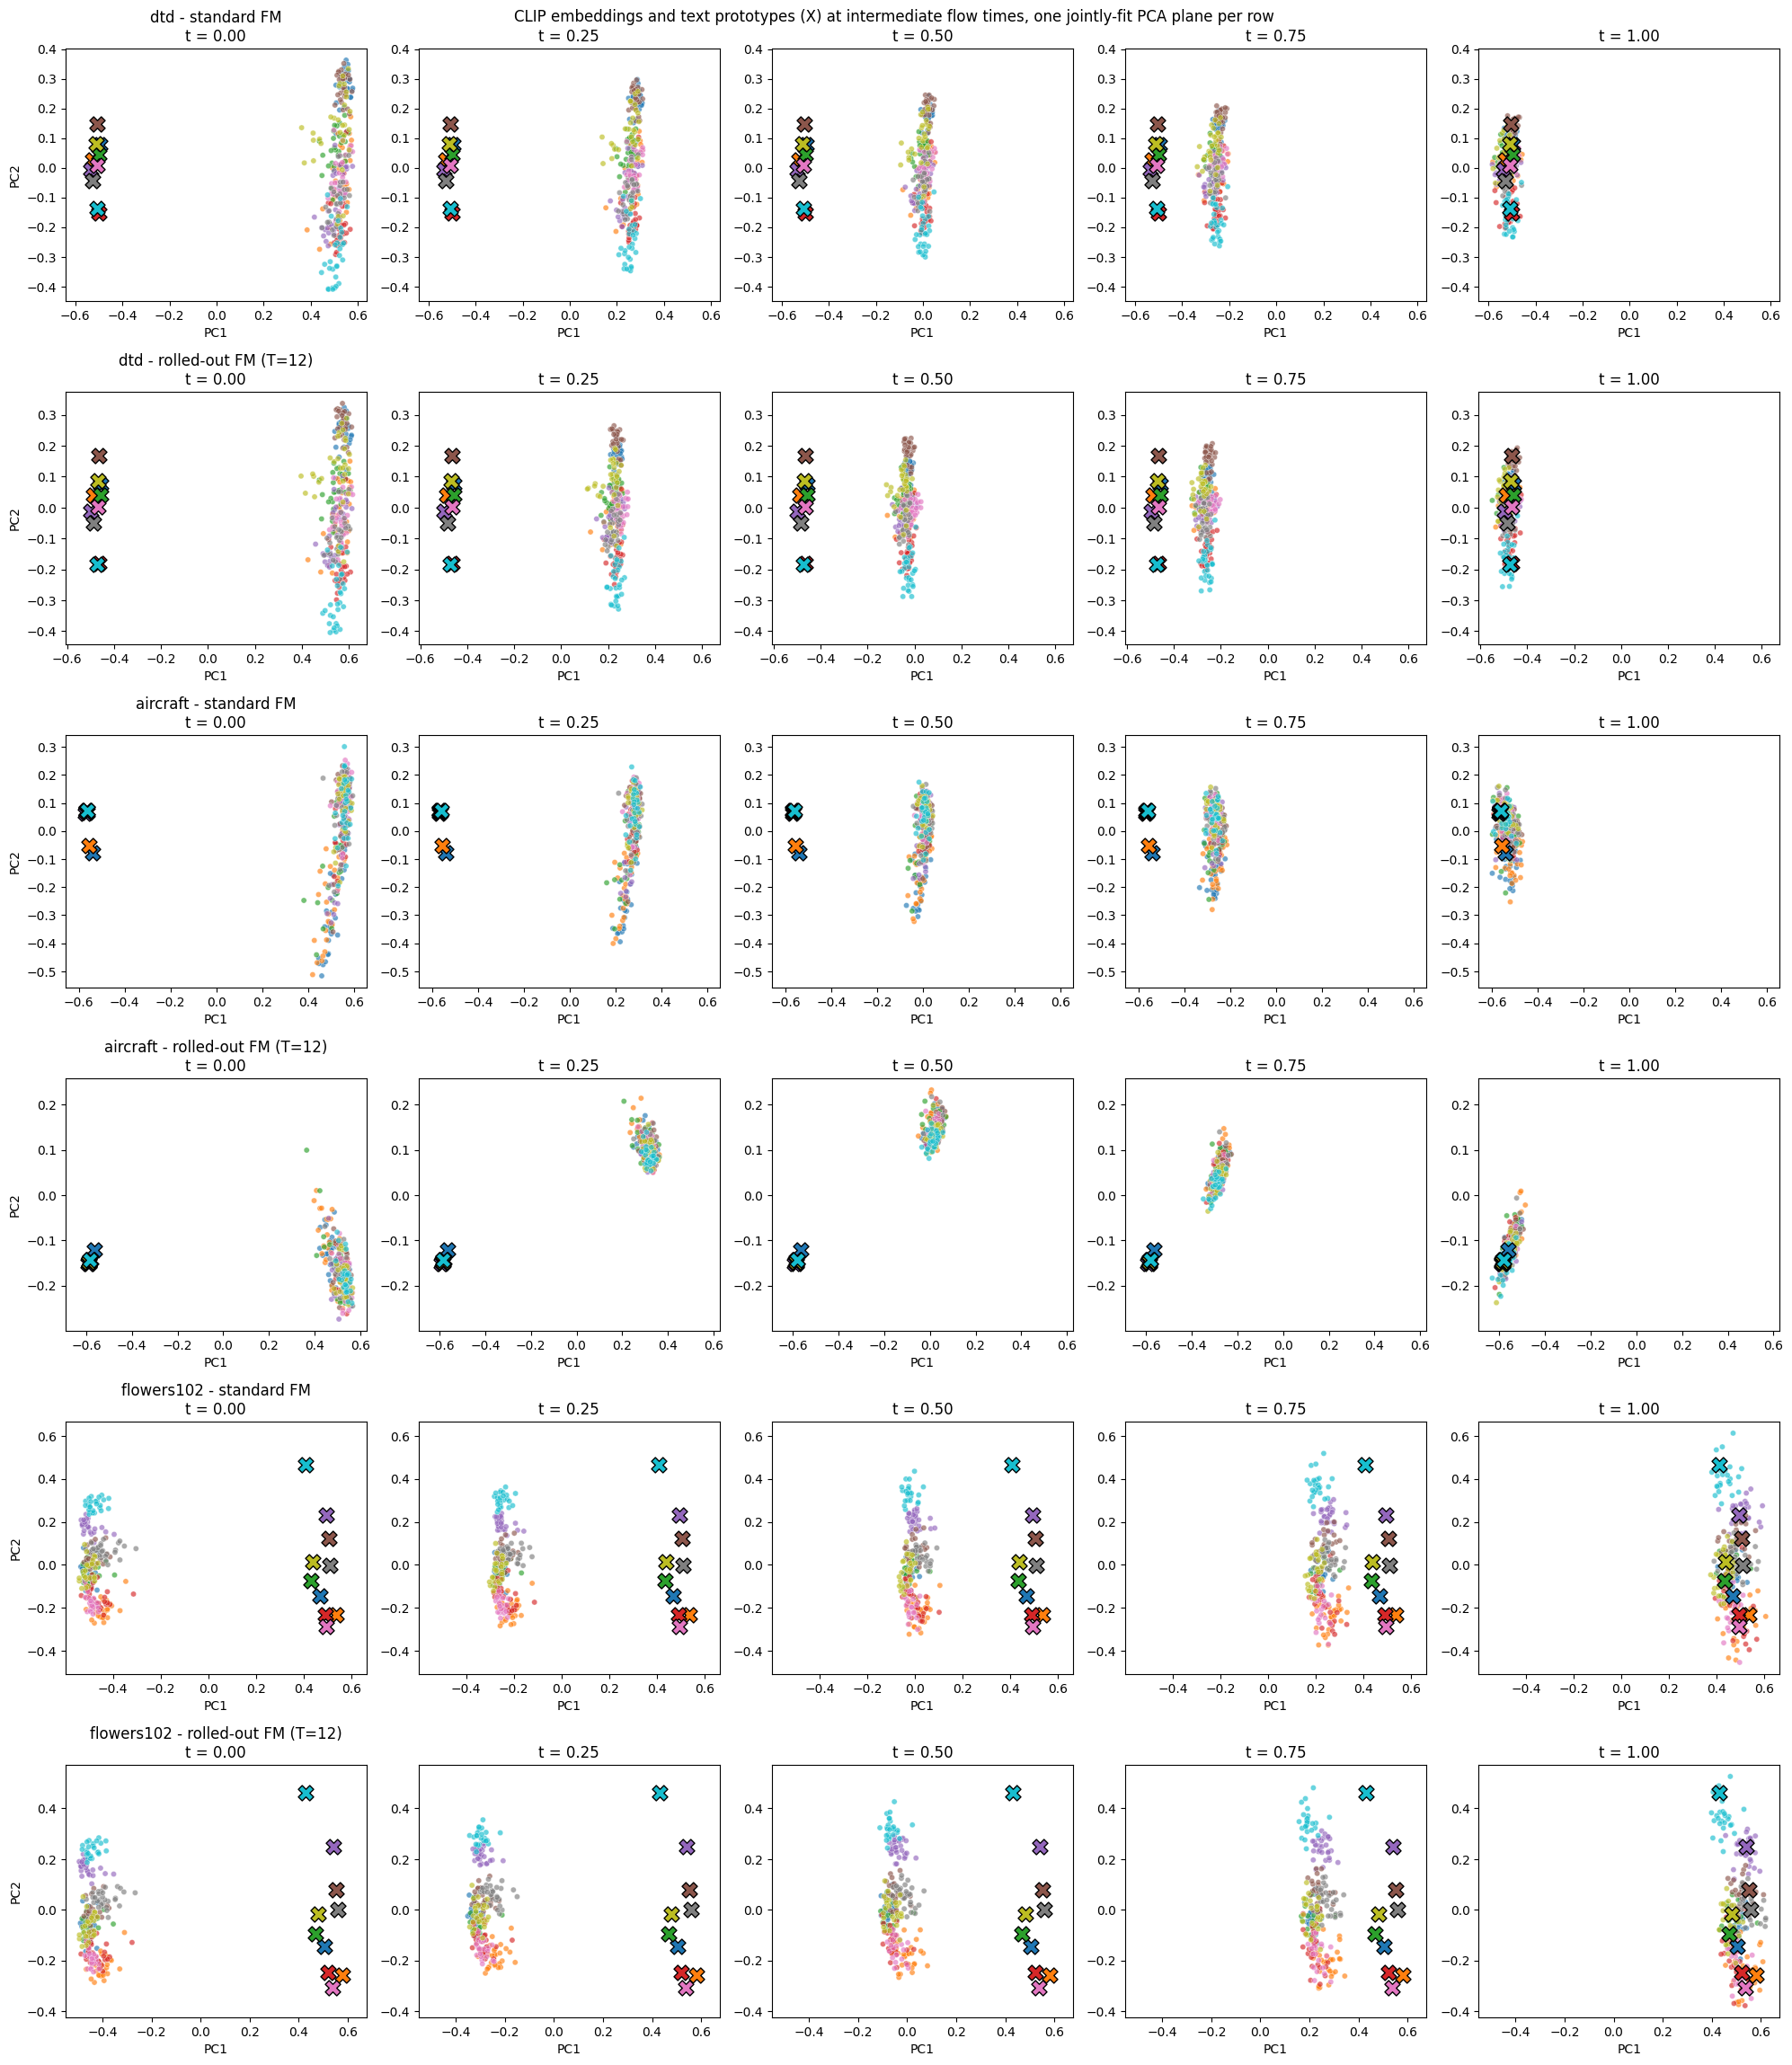

In [21]:
SNAPSHOT_STEPS = [0, INTERMEDIATE_T // 4, INTERMEDIATE_T // 2, 3 * INTERMEDIATE_T // 4, INTERMEDIATE_T]
panel_rows = [(d, m, lbl) for d in DATASETS for m, lbl in INTERMEDIATE_MODES]
fig, axes = plt.subplots(len(panel_rows), len(SNAPSHOT_STEPS),
                         figsize=(4 * len(SNAPSHOT_STEPS), 3.9 * len(panel_rows)), squeeze=False)
for i, (dataset_name, mode_tag, label) in enumerate(panel_rows):
    bank = feature_bank[dataset_name]['test']
    labels = bank['labels'].numpy()
    selected_classes = np.arange(10)
    sel = np.concatenate([np.flatnonzero(labels == c)[:30] for c in selected_classes])
    z = F.normalize(bank['features'][sel].float(), dim=1).to(DEVICE)
    y = labels[sel]
    prototypes = text_bank[dataset_name].to(DEVICE)
    net = load_trained_network(dataset_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED, 0, mode_tag, z.shape[1])
    with torch.no_grad():
        _, traj = euler_rollout(net, z, INTERMEDIATE_T, return_trajectory=True)
    states = [traj[k].cpu().numpy() for k in SNAPSHOT_STEPS]
    protos_np = prototypes[selected_classes].cpu().numpy()
    pca = PCA(n_components=2).fit(np.concatenate(states + [protos_np]))
    state_xy = [pca.transform(s) for s in states]; proto_xy = pca.transform(protos_np)
    allxy = np.concatenate(state_xy + [proto_xy])
    pad = 0.05 * np.ptp(allxy, axis=0)
    xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
    ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])
    palette = sns.color_palette('tab10', 10)
    for j, (k, xy) in enumerate(zip(SNAPSHOT_STEPS, state_xy)):
        ax = axes[i, j]
        sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=y, palette=palette, s=20, alpha=.65, ax=ax, legend=False)
        for c_idx in range(len(selected_classes)):
            ax.scatter(proto_xy[c_idx, 0], proto_xy[c_idx, 1], color=palette[c_idx], marker='X',
                       s=150, edgecolors='black', zorder=5)
        header = f'{dataset_name} - {label}\n' if j == 0 else ''
        ax.set(title=f'{header}t = {k / INTERMEDIATE_T:.2f}', xlabel='PC1',
               ylabel='PC2' if j == 0 else '', xlim=xlim, ylim=ylim)
fig.suptitle('CLIP embeddings and text prototypes (X) at intermediate flow times, one jointly-fit PCA plane per row')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'intermediate_flow_time_snapshots.png', dpi=180, bbox_inches='tight'); plt.show()

## 19. Paired ΔAcc against the control, confidence intervals, and significance

Section 12's `delta_vs_control` is a difference of two independently-averaged means. That throws away the fact that the FM run and the control run at repetition *s* were built from **the same K images**, so the per-run difference `Δ_s = Acc_FM,s − Acc_control,s` is a paired quantity with far lower variance than the two marginals suggest.

This matters more than it looks. The identical statistic applied to the image branch (`04` §14) cut its headline from *"improves in 66 of 72 cells"* to *"39 of 72 are distinguishable from zero"*. Until it is computed here, this branch's *"loses to the control in 28 of 36 cells"* is a difference of means and nothing stronger.

Two statistics, answering different questions:

- **Paired per-seed CI** (primary). Mean of `Δ_s` with a 95% t-interval over the repetitions. The unit of analysis is the *run*, so it accounts for the subset/initialization variance that actually differs between repetitions. With `n=3` the interval is wide, which is honest rather than unfortunate.
- **McNemar** (secondary). The control and FM predict on the *same test images*, so their disagreements are paired and can be tested directly on the discordant counts. But McNemar's unit is the test image, not the run: it ignores seed variance entirely and is therefore anti-conservative here. Where the two disagree, trust the CI.

At `K=full` the control is a single deterministic closed-form run — a mean over the whole training split has nothing to reseed — so all three FM repetitions are differenced against one control and the spread reflects FM initialization variance alone. That is stated in the table via `variance_source` rather than left for the reader to infer.

**The comparison against zero-shot is deliberately not paired.** The zero-shot baseline is one number per dataset, with no repetitions and no labelled subset, so there is nothing to pair it with. That asymmetry is the whole reason the control exists.

In [ ]:
from scipy import stats


def control_run(dataset_name, shot, seed):
    """The K-shot control run this FM run is compared against: same CLIP features, same subset."""
    row = control_df[(control_df.dataset == dataset_name) & (control_df.shot == str(shot))
                     & (control_df.seed == seed)]
    pred_path = CONTROL_ROOT / dataset_name / str(shot) / f'seed_{seed}' / 'test_predictions.npy'
    if row.empty or not pred_path.exists():
        raise FileNotFoundError(
            f'Missing control run for {dataset_name}/{shot}/seed {seed} at {pred_path}. '
            f'Re-run Section 9 - it now saves per-run control predictions.')
    return float(row.test_accuracy.iloc[0]), np.load(pred_path)


def fm_eval_dir(row):
    subset_seed = None if pd.isna(row.subset_seed) else int(row.subset_seed)
    run_tag = f'subset_{subset_seed}__init_{int(row.init_seed)}'
    base = OUTPUT_ROOT / 'runs' / row.dataset / ENCODER_TAG / str(row.shot)
    if row.variant == 'standard':
        return base / 'standard' / run_tag / f'eval_T{int(row.T)}'
    return base / f'rollout_T{int(row.T)}' / run_tag / 'eval'


def mcnemar_p(b, c):
    """Two-sided McNemar on the discordant pairs: b = control-only correct, c = FM-only correct."""
    n = b + c
    if n == 0:
        return 1.0
    if n < 25:  # exact binomial; the chi-square approximation is unreliable this small
        try:
            return float(stats.binomtest(min(b, c), n, 0.5).pvalue)
        except AttributeError:  # scipy < 1.7
            return float(stats.binom_test(min(b, c), n, 0.5))
    return float(stats.chi2.sf((abs(b - c) - 1) ** 2 / n, 1))


paired_rows = []
for row in results_df.itertuples():
    shot = str(row.shot)
    # K-shot pairs on the subset seed - FM and the control saw the same K images. At K=full the
    # control is one deterministic closed-form run shared by all three FM repetitions.
    ctl_seed = 0 if shot == 'full' else int(row.subset_seed)
    ctl_acc, ctl_pred = control_run(row.dataset, shot, ctl_seed)
    fm_pred = np.load(fm_eval_dir(row) / 'test_predictions.npy')
    y_true = feature_bank[row.dataset]['test']['labels'].numpy()
    assert len(fm_pred) == len(ctl_pred) == len(y_true), 'prediction arrays are not the same test split'
    ctl_ok, fm_ok = ctl_pred == y_true, fm_pred == y_true
    b = int((ctl_ok & ~fm_ok).sum())   # control right, FM wrong
    c = int((~ctl_ok & fm_ok).sum())   # FM right, control wrong
    paired_rows.append(dict(dataset=row.dataset, shot=shot, variant=row.variant, T=int(row.T),
                            seed=ctl_seed if shot != 'full' else int(row.init_seed),
                            control_accuracy=ctl_acc, fm_accuracy=row.test_accuracy,
                            delta=row.test_accuracy - ctl_acc, n_control_only=b, n_fm_only=c,
                            mcnemar_p=mcnemar_p(b, c), n_test=len(y_true)))

paired_runs = pd.DataFrame(paired_rows)
paired_runs.to_csv(OUTPUT_ROOT / 'paired_delta_vs_control_per_run.csv', index=False)


def summarize(group):
    d = group.delta.to_numpy()
    n = len(d)
    mean = float(d.mean())
    sd = float(d.std(ddof=1)) if n > 1 else float('nan')
    half = float(stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n)) if n > 1 and np.isfinite(sd) else float('nan')
    return pd.Series(dict(
        runs=n, mean_delta=mean, std_delta=sd, ci95_low=mean - half, ci95_high=mean + half,
        significant=bool(np.isfinite(half) and (mean - half) * (mean + half) > 0),
        median_mcnemar_p=float(group.mcnemar_p.median()),
        seeds_mcnemar_sig=int((group.mcnemar_p < 0.05).sum()),
        mean_fm_only=float(group.n_fm_only.mean()),
        mean_control_only=float(group.n_control_only.mean())))


paired_summary = (paired_runs.groupby(['dataset', 'shot', 'variant', 'T'])
                  .apply(summarize).reset_index()
                  .merge(subset_diagnostics[['dataset', 'shot', 'effective_repetitions']],
                         on=['dataset', 'shot'], how='left'))
paired_summary['variance_source'] = np.where(paired_summary.shot == 'full',
                                             'network initialization', 'K-shot subset')
paired_summary.to_csv(OUTPUT_ROOT / 'paired_delta_vs_control_summary.csv', index=False)

n_cond = len(paired_summary)
sig = paired_summary[paired_summary.significant]
n_pos = int((sig.mean_delta > 0).sum())
n_neg = int((sig.mean_delta < 0).sum())
degenerate = int((sig.std_delta.fillna(0) == 0).sum())
print(f'Paired dAcc against the K-shot control over {n_cond} (dataset, K, variant, T) conditions.')
print(f'  95% CI excludes zero in {len(sig)}: {n_pos} favour FM, {n_neg} favour the control.')
if degenerate:
    print(f'  Of those, {degenerate} are DEGENERATE (std = 0 by construction, not by low variance) -')
    print(f'  Flowers-102 at K=10 is one effective repetition, so its interval collapses to a point.')
print(f'  {n_cond - len(sig)} cannot be called either way: report as no measurable difference.')
print('  McNemar treats test images as the unit and ignores seed variance, so it is anti-conservative')
print('  here; where the two disagree, the seed-level CI is the one to trust.')
display(paired_summary.sort_values('mean_delta').style.format({
    'mean_delta': '{:+.4f}', 'std_delta': '{:.4f}', 'ci95_low': '{:+.4f}', 'ci95_high': '{:+.4f}',
    'median_mcnemar_p': '{:.3g}', 'mean_fm_only': '{:.1f}', 'mean_control_only': '{:.1f}'}))

### 19b. Supplement: the same paired test with more repetitions

Same argument as `04` §14b, and the same separation of concerns: the required table in Section 12 keeps Stage 1's 3-repetition protocol, and this supplement re-runs the identical protocol with seeds 3–9 in a separate `extended/` tree purely to raise statistical resolution. The t-multiplier falls from 4.30 (df=2) to 2.26 (df=9) and the standard error by `√(10/3)`, so intervals narrow by roughly 3.4× on the same effect.

This branch is the one that needs it most. Its headline — *"loses to the control in 28 of 36 cells"* — currently rests on differences of means, and Section 19 above only puts intervals on them at `n=3`. Whether those losses are real or unresolvable is exactly what this answers.

The reference is the **K-shot control**, recomputed per seed. It is closed form, so extra seeds cost nothing on the baseline side; only the FM networks are trained. As in `04` §14b, each extra repetition varies the subset seed and the initialization seed together, so the interval covers total run-to-run variance.

In [ ]:
EXTENDED_SEEDS = list(range(10))   # the required table keeps [0, 1, 2]
RUN_EXTENDED = False               # set True for one pass to train the extra repetitions
EXTENDED_ROOT = OUTPUT_ROOT / 'extended'


def control_for_seed(bank, shot, seed, n_classes):
    """The closed-form K-shot control for an arbitrary seed. Costs nothing to recompute."""
    x_train, y_train = bank['train']['features'].float(), bank['train']['labels'].long()
    if shot != 'full':
        idx = torch.as_tensor(balanced_indices(y_train.numpy(), int(shot), seed))
        xs, ys = x_train[idx], y_train[idx]
    else:
        xs, ys = x_train, y_train
    protos = make_prototypes(xs, ys, n_classes)
    x_test, y_test = bank['test']['features'].float(), bank['test']['labels'].long()
    pred, _ = classify_cosine(x_test, protos)
    return float((pred == y_test).float().mean()), pred.numpy()


def extended_rows_for(dataset_name, shot, seed):
    """One repetition of the (standard, rollout T=4, rollout T=12) triple at `seed`."""
    bank = feature_bank[dataset_name]
    n_classes = len(bank['test']['classes'])
    ctl_acc, ctl_pred = control_for_seed(bank, shot, seed, n_classes)
    prototypes = text_bank[dataset_name].to(DEVICE)   # fixed text prototypes, K-independent

    x_train_raw, y_train_full = bank['train']['features'].float(), bank['train']['labels'].long()
    if shot != 'full':
        idx = torch.as_tensor(balanced_indices(y_train_full.numpy(), int(shot), seed))
        x_train_raw, y_train = x_train_raw[idx], y_train_full[idx]
    else:
        y_train = y_train_full
    x_train = F.normalize(x_train_raw, dim=1).to(DEVICE); y_train = y_train.to(DEVICE)
    x_val = F.normalize(bank['val']['features'].float(), dim=1).to(DEVICE)
    y_val = bank['val']['labels'].long().to(DEVICE)
    x_test = F.normalize(bank['test']['features'].float(), dim=1).to(DEVICE)
    y_test = bank['test']['labels'].long().to(DEVICE)
    y_true = bank['test']['labels'].numpy()
    run_tag = f'rep_{seed}'
    base = EXTENDED_ROOT / 'runs' / dataset_name / ENCODER_TAG / str(shot)

    out = []

    def record(variant, T, fm_acc, fm_pred):
        ctl_ok, fm_ok = ctl_pred == y_true, fm_pred == y_true
        b = int((ctl_ok & ~fm_ok).sum())
        c = int((~ctl_ok & fm_ok).sum())
        out.append(dict(dataset=dataset_name, shot=str(shot), variant=variant, T=int(T), seed=seed,
                        control_accuracy=ctl_acc, fm_accuracy=fm_acc, delta=fm_acc - ctl_acc,
                        n_control_only=b, n_fm_only=c, mcnemar_p=mcnemar_p(b, c),
                        n_test=len(y_true)))

    net, _, _, _, _, _ = train_velocity_network(
        'standard', x_train, y_train, prototypes, x_val, y_val, base / 'standard' / run_tag,
        dataset_name, shot, seed, seed)
    for T in FM['T_values']:
        acc, pred = evaluate_split(net, x_test, y_test, prototypes, T)
        record('standard', T, acc, pred.numpy())

    for T in FM['T_values']:
        net, _, _, _, _, _ = train_velocity_network(
            'rollout', x_train, y_train, prototypes, x_val, y_val,
            base / f'rollout_T{T}' / run_tag, dataset_name, shot, seed, seed, T=T)
        acc, pred = evaluate_split(net, x_test, y_test, prototypes, T)
        record('rollout', T, acc, pred.numpy())
    return out


extended_path = EXTENDED_ROOT / 'paired_delta_vs_control_extended_per_run.csv'
if RUN_EXTENDED:
    EXTENDED_ROOT.mkdir(parents=True, exist_ok=True)
    rows = []
    todo = [(d, s, seed) for d in DATASETS for s in SHOT_SETTINGS for seed in EXTENDED_SEEDS]
    for dataset_name, shot, seed in tqdm(todo, desc='extended repetitions'):
        rows.extend(extended_rows_for(dataset_name, shot, seed))
    extended_runs = pd.DataFrame(rows)
    extended_runs.to_csv(extended_path, index=False)
elif extended_path.exists():
    extended_runs = pd.read_csv(extended_path)
    extended_runs['shot'] = extended_runs['shot'].astype(str)
else:
    extended_runs = None
    print('Extended-repetition supplement not run. Set RUN_EXTENDED = True for one pass '
          f'(~{len(DATASETS) * len(SHOT_SETTINGS) * len(EXTENDED_SEEDS) * 3} velocity networks). '
          'The required table in Section 12 is unaffected either way.')

if extended_runs is not None:
    ext_summary = (extended_runs.groupby(['dataset', 'shot', 'variant', 'T'])
                   .apply(summarize).reset_index())
    ext_summary.to_csv(EXTENDED_ROOT / 'paired_delta_vs_control_extended_summary.csv', index=False)

    compare = (paired_summary[['dataset', 'shot', 'variant', 'T', 'mean_delta',
                               'ci95_low', 'ci95_high', 'significant']]
               .rename(columns={c: c + '_n3' for c in
                                ['mean_delta', 'ci95_low', 'ci95_high', 'significant']})
               .merge(ext_summary[['dataset', 'shot', 'variant', 'T', 'runs', 'mean_delta',
                                   'ci95_low', 'ci95_high', 'significant']]
                      .rename(columns={c: c + '_ext' for c in
                                       ['mean_delta', 'ci95_low', 'ci95_high', 'significant']}),
                      on=['dataset', 'shot', 'variant', 'T'], how='inner'))
    compare['width_n3'] = compare.ci95_high_n3 - compare.ci95_low_n3
    compare['width_ext'] = compare.ci95_high_ext - compare.ci95_low_ext
    compare['narrowing'] = compare.width_n3 / compare.width_ext.replace(0, np.nan)
    compare.to_csv(EXTENDED_ROOT / 'resolution_comparison.csv', index=False)

    n_reps = int(ext_summary.runs.max())
    beats = compare[compare.mean_delta_ext > 0]
    loses = compare[compare.mean_delta_ext < 0]
    print(f'Extended supplement: {n_reps} repetitions per cell, {len(compare)} cells vs n=3.')
    print(f'  CI excludes zero: {int(compare.significant_n3.sum())} at n=3 -> '
          f'{int(compare.significant_ext.sum())} at n={n_reps}.')
    print(f'  Median interval narrowing: {compare.narrowing.median():.1f}x.')
    print(f'  FM ahead of the control in {len(beats)} cells, behind in {len(loses)}; of the '
          f'{len(loses)} losses, {int(loses.significant_ext.sum())} are now resolvable as real.')
    print('The required table in Section 12 still reports n=3.')
    display(compare.sort_values('mean_delta_ext').style.format({
        'mean_delta_n3': '{:+.4f}', 'ci95_low_n3': '{:+.4f}', 'ci95_high_n3': '{:+.4f}',
        'mean_delta_ext': '{:+.4f}', 'ci95_low_ext': '{:+.4f}', 'ci95_high_ext': '{:+.4f}',
        'width_n3': '{:.4f}', 'width_ext': '{:.4f}', 'narrowing': '{:.1f}x'}))

## 20. Ablation: stopping the flow at a validation-selected time

Section 18's curves show accuracy peaking *before* `t=1` in **all six** curves on this branch — the rolled-out models leave as much as +4.2 points on the table by integrating to the end. Since the number of Euler steps actually taken is a free inference-time choice, that overshoot is recoverable.

**This is an ablation and is reported separately.** `ref/stage_2.pdf` specifies classifying `ẑ_T` after the full `T`-step sequence, and Section 12's table continues to do exactly that. Nothing here changes the required result.

The selection is made honestly: `t*` is the argmax of accuracy on the **validation** split, frozen, and only then evaluated once on test. Reading a peak off the *test* curve and reporting it would be selecting on the test set, which is why the `oracle_best` column — the best any `t` could have achieved on test — is shown alongside as the unreachable upper bound rather than as a result. The gap between `test_at_tstar` and `oracle_best` is the honest cost of not being allowed to peek.

Because the like-for-like reference on this branch is the K-shot control rather than a prototype baseline, `t*` is also reported against the control: `t1_vs_control` and `tstar_vs_control` say whether early stopping moves any setting from losing to the control into beating it.

In [ ]:
TSTAR_T = 12


def accuracy_by_step(net, x, y, prototypes, T, chunk=4096):
    """Top-1 accuracy at each of the T+1 Euler states, using the shared integrator."""
    net.eval()
    P = F.normalize(prototypes, dim=1)
    correct = np.zeros(T + 1)
    with torch.no_grad():
        for s in range(0, len(x), chunk):
            xb, yb = x[s:s + chunk], y[s:s + chunk]
            _, traj = euler_rollout(net, xb, T, return_trajectory=True)
            for k, z in enumerate(traj):
                correct[k] += float(((F.normalize(z, dim=1) @ P.T).argmax(1) == yb).sum().item())
    return correct / len(x)


TSTAR_MODES = [('standard', 'standard FM'), (f'rollout_T{TSTAR_T}', f'rolled-out FM (T={TSTAR_T})')]
tstar_rows = []
for dataset_name in tqdm(DATASETS, desc='validation-selected t*'):
    bank = feature_bank[dataset_name]
    x_val = F.normalize(bank['val']['features'].float(), dim=1).to(DEVICE)
    y_val = bank['val']['labels'].long().to(DEVICE)
    x_test = F.normalize(bank['test']['features'].float(), dim=1).to(DEVICE)
    y_test = bank['test']['labels'].long().to(DEVICE)
    # text prototypes carry no dependence on K or on the subset seed
    prototypes = text_bank[dataset_name].to(DEVICE)
    for shot in SHOT_SETTINGS:
        reps = [(s, 0) for s in SUBSET_SEEDS] if shot != 'full' else [(None, s) for s in INIT_SEEDS]
        for subset_seed, init_seed in reps:
            for mode_tag, label in TSTAR_MODES:
                net = load_trained_network(dataset_name, shot, subset_seed, init_seed,
                                           mode_tag, x_val.shape[1])
                # t* is chosen on VALIDATION only. The test curve is computed for reporting, but the
                # index read out of it was fixed before test was touched - no test information
                # enters the choice.
                val_curve = accuracy_by_step(net, x_val, y_val, prototypes, TSTAR_T)
                k_star = int(val_curve.argmax())
                test_curve = accuracy_by_step(net, x_test, y_test, prototypes, TSTAR_T)
                tstar_rows.append(dict(
                    dataset=dataset_name, shot=str(shot), model=label,
                    seed=init_seed if shot == 'full' else subset_seed,
                    t_star=k_star / TSTAR_T, val_accuracy_at_tstar=float(val_curve[k_star]),
                    val_accuracy_at_t1=float(val_curve[-1]),
                    test_accuracy_at_tstar=float(test_curve[k_star]),
                    test_accuracy_at_t1=float(test_curve[-1]),
                    gain_from_early_stop=float(test_curve[k_star] - test_curve[-1]),
                    test_best_possible=float(test_curve.max())))

tstar_runs = pd.DataFrame(tstar_rows)
tstar_runs.to_csv(OUTPUT_ROOT / 'validation_selected_tstar_runs.csv', index=False)
tstar_summary = tstar_runs.groupby(['dataset', 'shot', 'model'], as_index=False).agg(
    mean_t_star=('t_star', 'mean'),
    test_at_t1=('test_accuracy_at_t1', 'mean'),
    test_at_tstar=('test_accuracy_at_tstar', 'mean'),
    gain=('gain_from_early_stop', 'mean'),
    gain_std=('gain_from_early_stop', 'std'),
    oracle_best=('test_best_possible', 'mean'))
tstar_summary['oracle_gap'] = tstar_summary.oracle_best - tstar_summary.test_at_tstar
# the control is the like-for-like reference on this branch, so measure t* against it too
tstar_summary = tstar_summary.merge(control_summary[['dataset', 'shot', 'control_mean_accuracy']],
                                    on=['dataset', 'shot'], how='left')
tstar_summary['t1_vs_control'] = tstar_summary.test_at_t1 - tstar_summary.control_mean_accuracy
tstar_summary['tstar_vs_control'] = tstar_summary.test_at_tstar - tstar_summary.control_mean_accuracy
tstar_summary.to_csv(OUTPUT_ROOT / 'validation_selected_tstar_summary.csv', index=False)

assert (tstar_runs.test_accuracy_at_tstar <= tstar_runs.test_best_possible + 1e-9).all(), (
    'test accuracy at the validation-selected t* exceeds the test-curve maximum, which is impossible '
    'unless t* was selected on test')

print('ABLATION - not part of the required Stage 2 table, which always classifies the final state z_T.')
print(f'Integration is stopped at t* = argmax of VALIDATION accuracy over the T={TSTAR_T} Euler grid,')
print('then test is evaluated once at that t*. "oracle_best" is the best the test curve could have')
print('reached at any t; the gap to it is the price of choosing t* honestly on validation.')
improved = int((tstar_summary.gain > 0).sum())
print(f'Early stopping the flow helps in {improved} of {len(tstar_summary)} conditions '
      f'(mean gain {tstar_summary.gain.mean():+.4f}, best {tstar_summary.gain.max():+.4f}).')
flipped = int(((tstar_summary.t1_vs_control < 0) & (tstar_summary.tstar_vs_control > 0)).sum())
print(f'Conditions that lose to the K-shot control at t=1 but beat it at t*: {flipped} of '
      f'{len(tstar_summary)}.')
display(tstar_summary.sort_values('gain', ascending=False).style.format({
    'mean_t_star': '{:.3f}', 'test_at_t1': '{:.4f}', 'test_at_tstar': '{:.4f}',
    'gain': '{:+.4f}', 'gain_std': '{:.4f}', 'oracle_best': '{:.4f}', 'oracle_gap': '{:.4f}',
    'control_mean_accuracy': '{:.4f}', 't1_vs_control': '{:+.4f}', 'tstar_vs_control': '{:+.4f}'}))

## 21. Animated flow trajectories

The same transport played through time, standard FM and rolled-out FM side by side from an identical starting embedding, so what differs on screen is purely the training objective. At each step an arrow shows the actual update applied, `(1/T) * v_theta(z_k, k/T)`, projected into the plot plane.

The dataset is **chosen programmatically** as the one with the largest gain over the K-shot control - the honest comparison, not the zero-shot one - so the animation shows where the FM layer itself does the most work. Everything comes from the saved checkpoints; the cell asserts `T+1` states, an identical start for both models, and no gradients.

**Read qualitatively.** Transport happens in CLIP's full 1024-dimensional space; this is a 2-D projection, so projected path length, curvature, and arrow direction are not high-dimensional measurements.

Animating the largest control-relative gain: dtd (shot full, standard T=12, delta vs control +0.0348)
[OK] 3 examples, 13 states each, both models share the same start
[OK] example 0 -> flow_animation_dtd_ex0.gif



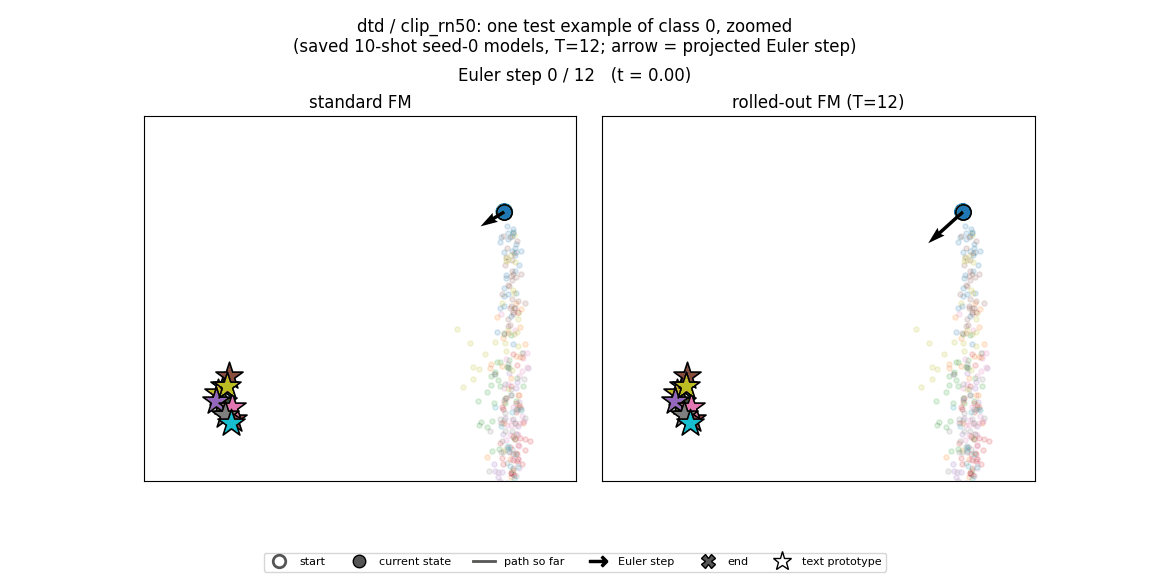

[OK] example 1 -> flow_animation_dtd_ex1.gif



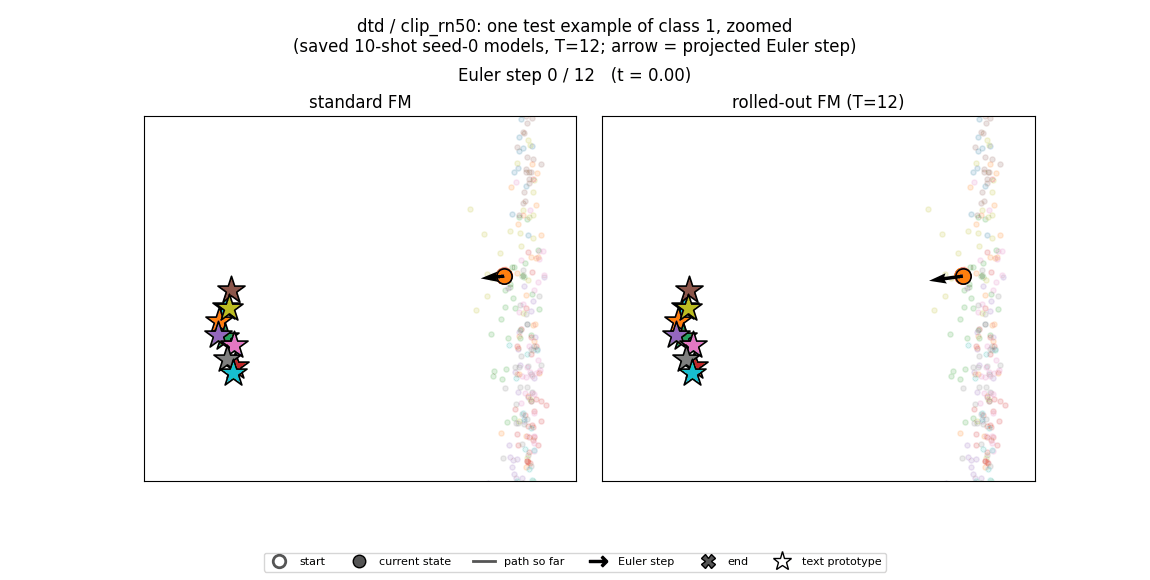

[OK] example 2 -> flow_animation_dtd_ex2.gif



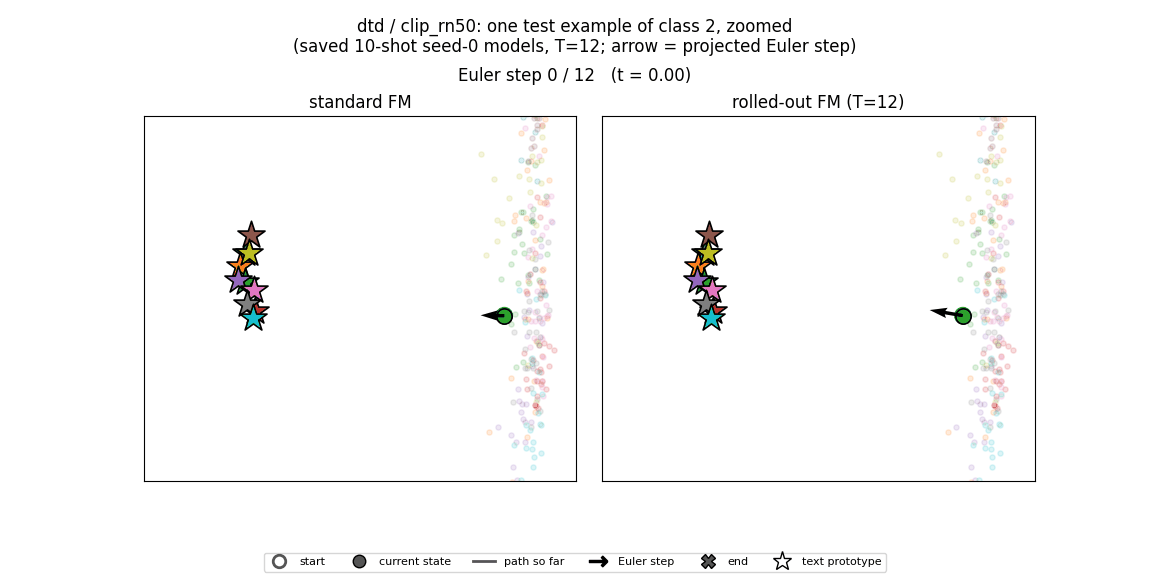

Artifacts saved to: /content/drive/MyDrive/Flow-Matching/outputs/flow_matching_clip


In [22]:
import base64
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import HTML

# Largest gain over the K-shot control - the comparison that isolates the FM layer.
_best = comparison.loc[comparison.delta_vs_control.idxmax()]
ANIM_DATASET = str(_best.dataset)
ANIM_T, N_EXAMPLES = INTERMEDIATE_T, 3
print(f'Animating the largest control-relative gain: {ANIM_DATASET} '
      f'(shot {_best.shot}, {_best.variant} T={_best["T"]}, delta vs control {_best.delta_vs_control:+.4f})')

bank = feature_bank[ANIM_DATASET]['test']
labels = bank['labels'].numpy()
selected_classes = np.arange(10)
sel = np.concatenate([np.flatnonzero(labels == c)[:30] for c in selected_classes])
z_bg = F.normalize(bank['features'][sel].float(), dim=1).to(DEVICE)
y_bg = labels[sel]
protos_t = text_bank[ANIM_DATASET].to(DEVICE)
nets = {tag: load_trained_network(ANIM_DATASET, INTERMEDIATE_SHOT, INTERMEDIATE_SEED, 0, tag,
                                  z_bg.shape[1]) for tag, _ in INTERMEDIATE_MODES}

ex_idx = [int(np.flatnonzero(y_bg == c)[0]) for c in selected_classes[:N_EXAMPLES]]
z_ex = z_bg[ex_idx]
trajs = {}
for tag, net in nets.items():
    with torch.no_grad():
        _, tr = euler_rollout(net, z_ex, ANIM_T, return_trajectory=True)
    stacked = torch.stack(tr)
    assert stacked.shape[0] == ANIM_T + 1, 'trajectory must have T+1 states'
    assert torch.allclose(stacked[0], z_ex), 'trajectory must start from the untouched embedding'
    assert not stacked.requires_grad, 'no gradients during trajectory generation'
    trajs[tag] = stacked.cpu().numpy()
tag_a, tag_b = INTERMEDIATE_MODES[0][0], INTERMEDIATE_MODES[1][0]
assert np.allclose(trajs[tag_a][0], trajs[tag_b][0]), 'both models must start from identical embeddings'
print(f'[OK] {N_EXAMPLES} examples, {ANIM_T + 1} states each, both models share the same start')

protos_np = protos_t[selected_classes].cpu().numpy()
pca = PCA(n_components=2).fit(np.concatenate(
    [z_bg.cpu().numpy()] + [trajs[t].reshape(-1, z_bg.shape[1]) for t, _ in INTERMEDIATE_MODES] + [protos_np]))
bg_xy, proto_xy = pca.transform(z_bg.cpu().numpy()), pca.transform(protos_np)
traj_xy = {tag: np.stack([pca.transform(trajs[tag][:, i]) for i in range(N_EXAMPLES)])
           for tag, _ in INTERMEDIATE_MODES}
palette = sns.color_palette('tab10', 10)
LEGEND = [Line2D([], [], marker='o', ls='', ms=9, mfc='none', mec='#555555', mew=2, label='start'),
          Line2D([], [], marker='o', ls='', ms=9, color='#555555', mec='black', label='current state'),
          Line2D([], [], color='#555555', lw=2, label='path so far'),
          Line2D([], [], marker=r'$\rightarrow$', ls='', ms=13, color='black', label='Euler step'),
          Line2D([], [], marker='X', ls='', ms=10, color='#555555', mec='black', label='end'),
          Line2D([], [], marker='*', ls='', ms=14, mfc='white', mec='black', label='text prototype')]

def animate_example(i):
    cls = int(y_bg[ex_idx[i]]); color = palette[cls]
    pts = np.concatenate([traj_xy[t][i] for t, _ in INTERMEDIATE_MODES] + [proto_xy[cls:cls + 1]])
    lo, hi = pts.min(0), pts.max(0); pad = 0.25 * max(float(np.max(hi - lo)), 1e-6)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.8))
    fig.subplots_adjust(top=0.80, bottom=0.17, wspace=0.06)
    panels = []
    for ax, (tag, label) in zip(axes, INTERMEDIATE_MODES):
        xy = traj_xy[tag][i]
        for c in range(10):
            m = y_bg == c
            ax.scatter(bg_xy[m, 0], bg_xy[m, 1], s=14, alpha=.15, color=palette[c])
            ax.scatter(proto_xy[c, 0], proto_xy[c, 1], marker='*', s=420, color=palette[c],
                       edgecolors='black', linewidths=1.2, zorder=5)
        ax.scatter([xy[0, 0]], [xy[0, 1]], s=110, facecolors='none', edgecolors=color,
                   linewidths=2.2, zorder=6)
        trail, = ax.plot([], [], color=color, lw=2.0, zorder=4)
        cur, = ax.plot([], [], marker='o', ms=11, color=color, mec='black', mew=1.2, zorder=7)
        arrow = ax.quiver([xy[0, 0]], [xy[0, 1]], [0.], [0.], angles='xy', scale_units='xy',
                          scale=1.0, color='black', width=0.008, zorder=8)
        fin = ax.scatter([], [], marker='X', s=140, color=color, edgecolors='black', zorder=9, visible=False)
        ax.set(xlim=(lo[0] - pad, hi[0] + pad), ylim=(lo[1] - pad, hi[1] + pad), title=label,
               xticks=[], yticks=[])
        panels.append(dict(trail=trail, cur=cur, arrow=arrow, fin=fin, xy=xy))
    step_txt = fig.text(0.5, 0.86, '', ha='center', fontsize=12)
    fig.legend(handles=LEGEND, loc='lower center', bbox_to_anchor=(0.5, 0.005), ncol=6, fontsize=8)
    fig.suptitle(f'{ANIM_DATASET} / {ENCODER_TAG}: one test example of class {cls}, zoomed\n'
                 f'(saved 10-shot seed-0 models, T={ANIM_T}; arrow = projected Euler step)',
                 y=0.97, fontsize=12)

    def draw(k):
        for p in panels:
            xy = p['xy']
            p['trail'].set_data(xy[:k + 1, 0], xy[:k + 1, 1])
            p['cur'].set_data([xy[k, 0]], [xy[k, 1]])
            if k < ANIM_T:
                p['arrow'].set_offsets(xy[k:k + 1])
                p['arrow'].set_UVC([xy[k + 1, 0] - xy[k, 0]], [xy[k + 1, 1] - xy[k, 1]])
                p['arrow'].set_visible(True)
            else:
                p['arrow'].set_visible(False)
            p['fin'].set_visible(k == ANIM_T)
            if k == ANIM_T: p['fin'].set_offsets(xy[-1:])
        step_txt.set_text(f'Euler step {k} / {ANIM_T}   (t = {k / ANIM_T:.2f})')
        return []

    frames = [0] * 3 + list(range(1, ANIM_T)) + [ANIM_T] * 4
    anim = FuncAnimation(fig, draw, frames=frames, interval=600, blit=False)
    path = OUTPUT_ROOT / f'flow_animation_{ANIM_DATASET}_ex{i}.gif'
    try:
        anim.save(path, writer=PillowWriter(fps=2))
    except Exception as err:
        print(f'[WARN] GIF export failed for example {i} ({err}); showing the final frame instead.')
        draw(ANIM_T); plt.show(); plt.close(fig); return None
    plt.close(fig)
    return path

for i in range(N_EXAMPLES):
    gif = animate_example(i)
    if gif is not None:
        print(f'[OK] example {i} -> {gif.name}')
        display(HTML('<img src="data:image/gif;base64,'
                     + base64.b64encode(gif.read_bytes()).decode('ascii') + '" width="900"/>'))
print('Artifacts saved to:', OUTPUT_ROOT)